<a href="https://colab.research.google.com/github/WaruCodes/Deep_Learning-Defect-prediction-framework-using-CodeBERT-and-GAT/blob/main/Final_Model_Transformers_CodeBERT_%2B_BiLSTM_%2B_GAT_%5BOnly_Buggy_Files%5D_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== Install only what is missing =====
!pip -q install transformers==4.41.0 torchmetrics==1.4.0 scikit-learn==1.6.0
!pip -q install tree_sitter==0.20.2 tree_sitter_languages
!pip -q install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.3.0+cu118.html

# ===== Imports =====
import os, sys, json, math, random, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import RobertaTokenizer, RobertaModel
from sklearn.metrics import (
    accuracy_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 61.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 72.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 50.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 80.7 MB/s eta 

In [ ]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/transformers_only/train_transformers.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/transformers_only/val_transformers.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/transformers_only/test_transformers.csv")


In [ ]:
train_commits = set(train_df["commit"])
val_commits = set(val_df["commit"])
test_commits = set(test_df["commit"])

print("Train ∩ Val:", len(train_commits & val_commits))
print("Train ∩ Test:", len(train_commits & test_commits))
print("Val ∩ Test:", len(val_commits & test_commits))

Train ∩ Val: 47
Train ∩ Test: 58
Val ∩ Test: 24


In [ ]:
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

# Data Loading and Preprocessing
Goal: Read your dataset rows, decode  as UTF‑8 (fixed file after commit), preserve exact line boundaries (including whitespace), and build labels from .

Line numbering: This notebook assumes  uses 0-based indices. If yours are 1-based, subtract 1 during preprocessing.

Commit/diff metadata: Optional functions are included to enrich samples later

In [ ]:
print("Train rows:", len(train_df), "Cols:", train_df.columns.tolist())
print("Val rows:", len(val_df), "Cols:", val_df.columns.tolist())
print("Test rows:", len(test_df), "Cols:", test_df.columns.tolist())

Train rows: 1644 Cols: ['datetime', 'commit', 'repo', 'filepath', 'content', 'methods', 'induce_bug']
Val rows: 94 Cols: ['datetime', 'commit', 'repo', 'filepath', 'content', 'methods', 'induce_bug']
Test rows: 107 Cols: ['datetime', 'commit', 'repo', 'filepath', 'content', 'methods', 'induce_bug']


In [ ]:
import json
import re
import pandas as pd
import requests

# Fix owner mapping here
REPO_OWNER_MAP = {
    "transformers": "huggingface",   # ✅ correct owner
}

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "line-level-bug-dataset/1.0"})


import ast
import json
import math
import numpy as np
import pandas as pd
import re

def parse_induce_bug(value):
    """
    Safely parse induce_bug into a sorted list of integer line numbers.
    Avoids extracting '64' from strings like 'np.int64(1327)'.
    """
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []

    if isinstance(value, (list, tuple, set)):
        out = []
        for v in value:
            if isinstance(v, (int, np.integer)):
                out.append(int(v))
            else:
                s = str(v).strip()
                m = re.fullmatch(r"(?:np\.)?int\d+\((\-?\d+)\)", s)
                if m:
                    out.append(int(m.group(1)))
                else:
                    try:
                        out.append(int(float(s)))
                    except Exception:
                        pass
        return sorted(set(out))

    if isinstance(value, (int, np.integer)):
        return [int(value)]

    s = str(value).strip()
    if not s:
        return []

    # remove wrappers like np.int64(1327) -> 1327
    s = re.sub(r"(?:np\.)?int\d+\((\-?\d+)\)", r"\1", s)

    # try JSON
    try:
        parsed = json.loads(s)
        if isinstance(parsed, list):
            out = []
            for v in parsed:
                if isinstance(v, (int, float, np.integer)) and not pd.isna(v):
                    out.append(int(v))
            return sorted(set(out))
    except Exception:
        pass

    # try Python literal
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            out = []
            for v in parsed:
                if isinstance(v, (int, float, np.integer)) and not pd.isna(v):
                    out.append(int(v))
            return sorted(set(out))
    except Exception:
        pass

    # fallback: only extract numbers that are standalone or inside brackets/commas
    nums = re.findall(r"(?<![A-Za-z])\-?\d+(?![A-Za-z])", s)
    return sorted(set(int(x) for x in nums))


def norm_path(filepath):
    return str(filepath).replace("\\", "/").lstrip("/")


def get_owner(row, repo):
    # if dataset has an 'owner' column, use it
    if "owner" in row and pd.notna(row["owner"]) and str(row["owner"]).strip():
        return str(row["owner"]).strip()

    # otherwise map
    if repo in REPO_OWNER_MAP:
        return REPO_OWNER_MAP[repo]

    # last resort heuristics
    if repo == "transformers":
        return "huggingface"

    raise KeyError(f"Unknown repo '{repo}'. Add it to REPO_OWNER_MAP or include an 'owner' column.")


def github_raw_url(owner, repo, ref, filepath):
    path = norm_path(filepath)
    return f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}"


def fetch_github_text(owner, repo, commit, filepath):
    """
    Try commit first. If 404, optionally try main/master as fallback.
    """
    url = github_raw_url(owner, repo, commit, filepath)
    r = SESSION.get(url, timeout=30)
    if r.status_code == 200:
        return r.text.replace("\r\n", "\n").replace("\r", "\n")

    # fallback attempts (sometimes datasets store branch name or bad commit)
    for ref in ("main", "master"):
        url2 = github_raw_url(owner, repo, ref, filepath)
        r2 = SESSION.get(url2, timeout=30)
        if r2.status_code == 200:
            return r2.text.replace("\r\n", "\n").replace("\r", "\n")

    raise RuntimeError(f"Fetch failed {r.status_code}: {url}")


def build_df_lines(split_df: pd.DataFrame, split_name: str):
    needed = ["repo", "commit", "filepath", "induce_bug"]
    for c in needed:
        if c not in split_df.columns:
            raise KeyError(f"{split_name} missing required column: '{c}'")

    df = split_df.dropna(subset=["filepath"]).copy()
    df["induce_bug"] = df["induce_bug"].apply(parse_induce_bug)
    df = df[df["induce_bug"].apply(len) > 0].reset_index(drop=True)

    rows, fail = [], []
    for i, row in df.iterrows():
        repo = str(row["repo"]).strip()
        commit = str(row["commit"]).strip()
        filepath = row["filepath"]

        try:
            owner = get_owner(row, repo)
            text = fetch_github_text(owner, repo, commit, filepath)
            lines = text.splitlines(keepends=True)
            bug_set = set(row["induce_bug"])

            for ln, line in enumerate(lines, start=1):
                rows.append({
                    "split": split_name,
                    "datetime": row.get("datetime", ""),
                    "owner": owner,
                    "repo": repo,
                    "commit": commit,
                    "filepath": norm_path(filepath),
                    "methods": row.get("methods", ""),
                    "line_no": ln,
                    "line_text": line,
                    "y": 1 if ln in bug_set else 0,
                })

        except Exception as e:
            fail.append((i, commit, filepath, str(e)))

    df_lines = pd.DataFrame(rows)
    print(f"{split_name}: files={len(df)}, lines={len(df_lines)}, failures={len(fail)}")
    if fail:
        print("First failure:", fail[0])
    return df, df_lines, fail


# Build per split
train_files, df_lines_train, fail_train = build_df_lines(train_df, "train")
val_files,   df_lines_val,   fail_val   = build_df_lines(val_df,   "val")
test_files,  df_lines_test,  fail_test  = build_df_lines(test_df,  "test")

print("Train y counts:\n", df_lines_train["y"].value_counts() if len(df_lines_train) else "EMPTY")
print("Val y counts:\n",   df_lines_val["y"].value_counts()   if len(df_lines_val)   else "EMPTY")
print("Test y counts:\n",  df_lines_test["y"].value_counts()  if len(df_lines_test)  else "EMPTY")

train: files=642, lines=667413, failures=0
val: files=9, lines=7852, failures=0
test: files=7, lines=6315, failures=0
Train y counts:
 y
0    642067
1     25346
Name: count, dtype: int64
Val y counts:
 y
0    7561
1     291
Name: count, dtype: int64
Test y counts:
 y
0    6258
1      57
Name: count, dtype: int64


In [ ]:
print(parse_induce_bug("[np.int64(1327), np.int64(1337)]"))

[1327, 1337]


In [ ]:
for i in range(5):
    raw = test_df.loc[i, "induce_bug"]
    parsed = parse_induce_bug(raw)
    print("RAW   :", raw)
    print("PARSED:", parsed)
    print("-" * 60)

RAW   : [np.int64(1327), np.int64(1337)]
PARSED: [1327, 1337]
------------------------------------------------------------
RAW   : [np.int64(30), np.int64(32), np.int64(602)]
PARSED: [30, 32, 602]
------------------------------------------------------------
RAW   : [np.int64(163), np.int64(457), np.int64(581)]
PARSED: [163, 457, 581]
------------------------------------------------------------
RAW   : [np.int64(114), np.int64(115), np.int64(116), np.int64(117), np.int64(118), np.int64(119), np.int64(120)]
PARSED: [114, 115, 116, 117, 118, 119, 120]
------------------------------------------------------------
RAW   : [np.int64(20), np.int64(1140), np.int64(1141), np.int64(1142), np.int64(1143), np.int64(1144), np.int64(1145), np.int64(1146), np.int64(1147), np.int64(1148), np.int64(1149), np.int64(1150), np.int64(1151), np.int64(1152), np.int64(1153), np.int64(1154), np.int64(1155), np.int64(1258), np.int64(1259), np.int64(1260), np.int64(1261), np.int64(1262), np.int64(1263), np.int64(

In [ ]:
row = test_df[test_df["filepath"].str.contains("modeling_tf_lxmert.py", na=False)].iloc[0]
print("RAW   :", row["induce_bug"])
print("PARSED:", parse_induce_bug(row["induce_bug"]))

RAW   : [np.int64(1327), np.int64(1337)]
PARSED: [1327, 1337]


In [ ]:
print(train_df[["repo","commit","filepath"]].head(5))
print("Unique repos:", train_df["repo"].unique()[:20])

           repo                                    commit  \
0  transformers  002a078aff3630e706456b5b615de083eb12c883   
1  transformers  002a078aff3630e706456b5b615de083eb12c883   
2  transformers  002a078aff3630e706456b5b615de083eb12c883   
3  transformers  01d340adfaea70ea0997931c92c498a5a18c7435   
4  transformers  01d340adfaea70ea0997931c92c498a5a18c7435   

                                       filepath  
0                src\transformers\file_utils.py  
1  src\transformers\models\auto\auto_factory.py  
2       src\transformers\models\auto\dynamic.py  
3            src\transformers\modeling_utils.py  
4                   src\transformers\trainer.py  
Unique repos: ['transformers']


In [ ]:
print("Train buggy lines:", int(df_lines_train["y"].sum()))
print("Val buggy lines:", int(df_lines_val["y"].sum()))
print("Test buggy lines:", int(df_lines_test["y"].sum()))

Train buggy lines: 25346
Val buggy lines: 291
Test buggy lines: 57


In [ ]:
def show_split_summary(split_name, df_files, df_lines, failures):
    print(f"\n=== {split_name.upper()} SUMMARY ===")
    print("Files with buggy lines:", len(df_files))
    print("Line-level rows:", len(df_lines))
    print("Failures:", len(failures))
    if failures:
        print("First failure:", failures[0])

    # sample buggy lines from first file in df_files
    if len(df_files) > 0 and len(df_lines) > 0:
        sample = df_files.iloc[0]
        sub = df_lines[
            (df_lines["commit"] == sample["commit"]) &
            (df_lines["filepath"] == sample["filepath"]) &
            (df_lines["y"] == 1)
        ][["line_no", "line_text"]]

        print("Sample bug lines:")
        print(sub.head(50).reset_index(drop=True))  # reset index removes confusing left index


# Call for all splits
show_split_summary("train", train_files, df_lines_train, fail_train)
show_split_summary("val",   val_files,   df_lines_val,   fail_val)
show_split_summary("test",  test_files,  df_lines_test,  fail_test)


=== TRAIN SUMMARY ===
Files with buggy lines: 642
Line-level rows: 667413
Failures: 0
Sample bug lines:
Empty DataFrame
Columns: [line_no, line_text]
Index: []

=== VAL SUMMARY ===
Files with buggy lines: 9
Line-level rows: 7852
Failures: 0
Sample bug lines:
Empty DataFrame
Columns: [line_no, line_text]
Index: []

=== TEST SUMMARY ===
Files with buggy lines: 7
Line-level rows: 6315
Failures: 0
Sample bug lines:
Empty DataFrame
Columns: [line_no, line_text]
Index: []


In [ ]:
# ===== PREPARE GROUPS FOR EACH SPLIT =====

def prepare_groups(df_lines):
    df_sorted = df_lines.sort_values(
        ["commit", "filepath", "line_no"]
    ).reset_index(drop=True)

    groups = df_sorted.groupby(["commit", "filepath"], sort=False)
    keys = list(groups.groups.keys())

    return df_sorted, groups, keys


df_train_sorted, train_groups, train_keys = prepare_groups(df_lines_train)
df_val_sorted,   val_groups,   val_keys   = prepare_groups(df_lines_val)
df_test_sorted,  test_groups,  test_keys  = prepare_groups(df_lines_test)

print("Train files:", len(train_keys))
print("Val files:", len(val_keys))
print("Test files:", len(test_keys))

Train files: 642
Val files: 9
Test files: 7


In [ ]:
import torch

def compute_class_weights_from_df(df_lines):

    y = df_lines["y"].values
    total = len(y)
    pos = (y == 1).sum()
    neg = (y == 0).sum()

    print("Total lines:", total)
    print("Buggy lines:", pos)
    print("Clean lines:", neg)
    print("Bug ratio:", pos / total if total > 0 else 0)

    if pos == 0 or neg == 0:
        print("Warning: dataset contains only one class.")
        return torch.tensor([1.0, 1.0], dtype=torch.float)

    w0 = total / (2.0 * neg)
    w1 = total / (2.0 * pos)

    weights = torch.tensor([w0, w1], dtype=torch.float)
    return weights


class_weights = compute_class_weights_from_df(df_lines_train).to(device)

print("Class weights:", class_weights)

Total lines: 667413
Buggy lines: 25346
Clean lines: 642067
Bug ratio: 0.037976485324679024
Class weights: tensor([ 0.5197, 13.1660], device='cuda:0')


In [ ]:
print(df_lines_train["y"].value_counts())

y
0    642067
1     25346
Name: count, dtype: int64


# Line tokenization and CodeBERT embeddings
Keep whitespace: We never strip or trim lines. We split by  exactly to preserve  alignment.
Embedding strategy: Use CodeBERT’s [CLS] embedding per line. Then contextualize with BiLSTM across lines to capture neighbors.

In [ ]:
import os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from transformers import RobertaTokenizer, RobertaModel
from sklearn.metrics import average_precision_score, precision_recall_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [ ]:
# =========================================================
# Build File Groups (used for window construction)
# =========================================================

def prepare_groups(df_lines):

    df_sorted = df_lines.sort_values(
        ["commit", "filepath", "line_no"]
    ).reset_index(drop=True)

    groups = df_sorted.groupby(
        ["commit", "filepath"],
        sort=False
    )

    keys = list(groups.groups.keys())

    return df_sorted, groups, keys


df_train_sorted, train_groups, train_keys = prepare_groups(df_lines_train)
df_val_sorted,   val_groups,   val_keys   = prepare_groups(df_lines_val)
df_test_sorted,  test_groups,  test_keys  = prepare_groups(df_lines_test)

print("Train files:", len(train_keys))
print("Val files:", len(val_keys))
print("Test files:", len(test_keys))

Train files: 642
Val files: 9
Test files: 7


In [ ]:
print("\nLabel distribution check")
print("Train buggy lines:", int(df_train_sorted["y"].sum()))
print("Val buggy lines:", int(df_val_sorted["y"].sum()))
print("Test buggy lines:", int(df_test_sorted["y"].sum()))


Label distribution check
Train buggy lines: 25346
Val buggy lines: 291
Test buggy lines: 57


In [ ]:
from torch.utils.data import Dataset

class WindowDataset(Dataset):
    def __init__(self, df_sorted, groups, keys, window=256, stride=128):
        self.df = df_sorted
        self.groups = groups
        self.keys = keys
        self.window = window
        self.stride = stride
        self.items = []  # list of (commit, filepath, start_idx, end_idx)

        for (commit, filepath) in self.keys:
            idxs = self.groups.groups[(commit, filepath)]
            L = len(idxs)
            s = 0
            while s < L:
                e = min(s + window, L)
                self.items.append((commit, filepath, s, e))
                if e == L:
                    break
                s += stride

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        commit, filepath, s, e = self.items[i]
        idxs = self.groups.groups[(commit, filepath)]
        chunk = self.df.iloc[idxs[s:e]]

        lines = chunk["line_text"].tolist()
        y = torch.tensor(chunk["y"].values, dtype=torch.long)

        meta = {
            "commit": commit,
            "filepath": filepath,
            "start": s,
            "end": e,
            "L": len(lines),
            # helpful for mapping back:
            "line_no_start": int(chunk["line_no"].iloc[0]),
        }
        return lines, y, meta

In [ ]:
import torch

WINDOW = 256
STRIDE = 128

train_win_ds = WindowDataset(df_train_sorted, train_groups, train_keys, window=WINDOW, stride=STRIDE)
val_win_ds   = WindowDataset(df_val_sorted,   val_groups,   val_keys,   window=WINDOW, stride=STRIDE)
test_win_ds  = WindowDataset(df_test_sorted,  test_groups,  test_keys,  window=WINDOW, stride=STRIDE)

print("Train windows:", len(train_win_ds))
print("Val windows:", len(val_win_ds))
print("Test windows:", len(test_win_ds))

Train windows: 4938
Val windows: 58
Test windows: 46


In [ ]:
#CodeBERT Emberder (Batch+Chunked)

tokenizer = RobertaTokenizer.from_pretrained("microsoft/codebert-base")
codebert = RobertaModel.from_pretrained("microsoft/codebert-base").to(device)
codebert.eval()

@torch.no_grad()
def embed_lines_batch_chunked(lines, max_len=128, chunk_size=32):
    """
    lines: list[str] length N
    returns: [N,768] on GPU
    """
    all_cls = []
    for s in range(0, len(lines), chunk_size):
        chunk = lines[s:s+chunk_size]
        enc = tokenizer(
            chunk, padding=True, truncation=True, max_length=max_len,
            return_tensors="pt"
        )
        input_ids = enc["input_ids"].to(device)
        attn_mask = enc["attention_mask"].to(device)

        out = codebert(input_ids=input_ids, attention_mask=attn_mask)
        cls = out.last_hidden_state[:, 0, :]  # [chunk,768]
        all_cls.append(cls.detach())

        del enc, input_ids, attn_mask, out, cls
        if device.type == "cuda":
            torch.cuda.empty_cache()

    return torch.cat(all_cls, dim=0)  # [N,768]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
import os
import torch
from tqdm import tqdm

# Example save folder
SAVE_DIR = "/content/drive/MyDrive/black_only/precomputed_codebert_windows"


def save_codebert_windows(window_ds, save_dir, split_name, max_len=128, chunk_size=32, fp16=True):
    """
    Save one .pt per window:
      {
        "X": [L,768],
        "y": [L],
        "meta": dict
      }
    """
    os.makedirs(save_dir, exist_ok=True)
    codebert.eval()

    for i in tqdm(range(len(window_ds)), desc=f"Precompute {split_name}"):
        lines, y, meta = window_ds[i]

        X = embed_lines_batch_chunked(
            lines,
            max_len=max_len,
            chunk_size=chunk_size
        )  # [L,768] on GPU

        X = X.cpu()
        if fp16:
            X = X.half()

        out = {
            "X": X,
            "y": y.cpu(),
            "meta": meta
        }

        torch.save(out, os.path.join(save_dir, f"{split_name}_{i:06d}.pt"))

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/black_only/precomputed_codebert_windows"

# Run ONCE:
save_codebert_windows(train_win_ds, SAVE_DIR, "train", max_len=128, chunk_size=32, fp16=True)
save_codebert_windows(val_win_ds,   SAVE_DIR, "val",   max_len=128, chunk_size=32, fp16=True)
save_codebert_windows(test_win_ds,  SAVE_DIR, "test",  max_len=128, chunk_size=32, fp16=True)

Precompute test: 100%|██████████| 46/46 [00:32<00:00,  1.44it/s]


In [ ]:
sample = torch.load(os.path.join(SAVE_DIR, "train_000000.pt"), map_location="cpu")
print(sample["X"].shape)
print(sample["y"].shape)
print(sample["meta"])
print(sample["y"][:20])

torch.Size([256, 768])
torch.Size([256])
{'commit': '002a078aff3630e706456b5b615de083eb12c883', 'filepath': 'src/transformers/file_utils.py', 'start': 0, 'end': 256, 'L': 256, 'line_no_start': 1}
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [ ]:
#Load Precomputed windows

class PrecomputedDataset(Dataset):
    def __init__(self, folder, split_name):
        self.folder = folder
        self.files = sorted([f for f in os.listdir(folder) if f.startswith(split_name) and f.endswith(".pt")])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        obj = torch.load(os.path.join(self.folder, self.files[idx]), map_location="cpu")
        X = obj["X"].float()   # [L,768]
        y = obj["y"].long()    # [L]
        meta = obj["meta"]
        return X, y, meta

def collate_precomputed(batch):
    Xs, Ys, metas = zip(*batch)
    lengths = [x.size(0) for x in Xs]
    Lmax = max(lengths)
    B = len(Xs)

    X = torch.zeros((B, Lmax, 768), dtype=torch.float32)
    Y = torch.full((B, Lmax), -100, dtype=torch.long)        # pad ignored
    mask = torch.zeros((B, Lmax), dtype=torch.bool)

    for i, (x, y) in enumerate(zip(Xs, Ys)):
        Li = x.size(0)
        X[i, :Li] = x
        Y[i, :Li] = y
        mask[i, :Li] = True

    return X.to(device), Y.to(device), mask.to(device), list(metas), lengths

In [ ]:
#Models

class CodeBERTOnlyHead(nn.Module):
    def __init__(self, in_dim=768, hidden=256, dropout=0.2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2)
        )
    def forward(self, X):  # [B,L,768]
        return self.mlp(X) # [B,L,2]

class ContextEncoder(nn.Module):
    def __init__(self, in_dim=768, hidden=256, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            in_dim, hidden, num_layers=num_layers,
            bidirectional=True, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.proj = nn.Linear(hidden*2, hidden*2)
        self.norm = nn.LayerNorm(hidden*2)

    def forward(self, x, lengths):  # x: [B,L,768]
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths=lengths, batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        h, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)  # [B,L,512]
        y = self.norm(torch.tanh(self.proj(h)))  # [B,L,512]
        return y

class BiLSTMHead(nn.Module):
    def __init__(self, in_dim=512, hidden=256, dropout=0.2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2)
        )
    def forward(self, H):  # [B,L,512]
        return self.mlp(H) # [B,L,2]

In [ ]:
#Metric Helpers

def flatten_valid_from_logits(logits_bl2, Y_bl):
    mask = (Y_bl != -100)
    y_true = Y_bl[mask].detach().cpu().numpy().astype(int)
    p_buggy = torch.softmax(logits_bl2, dim=-1)[..., 1][mask].detach().cpu().numpy()
    return y_true, p_buggy

def best_f1_threshold(y_true, p_buggy):
    prec, rec, thr = precision_recall_curve(y_true, p_buggy)
    if len(thr) == 0:
        return {"best_f1": 0.0, "best_thr": 0.5, "best_prec": 0.0, "best_rec": 0.0}
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    i = int(np.argmax(f1))
    return {"best_f1": float(f1[i]), "best_thr": float(thr[i]),
            "best_prec": float(prec[i]), "best_rec": float(rec[i])}

@torch.no_grad()
def eval_codebert_only(head, loader):
    head.eval()
    ys, ps = [], []
    for X, Y, mask, metas, lengths in loader:
        logits = head(X)
        y_true, p_buggy = flatten_valid_from_logits(logits, Y)
        if len(y_true) > 0:
            ys.append(y_true); ps.append(p_buggy)

    if not ys:
        return {"PR_AUC_AP": 0.0, "best_f1": 0.0, "best_thr": 0.5, "best_prec": 0.0, "best_rec": 0.0}

    y_true = np.concatenate(ys)
    p_buggy = np.concatenate(ps)
    ap = average_precision_score(y_true, p_buggy)
    best = best_f1_threshold(y_true, p_buggy)
    return {"PR_AUC_AP": float(ap), **best}

@torch.no_grad()
def eval_codebert_bilstm(context_encoder, head, loader):
    context_encoder.eval()
    head.eval()
    ys, ps = [], []
    for X, Y, mask, metas, lengths in loader:
        H = context_encoder(X, lengths)
        logits = head(H)
        y_true, p_buggy = flatten_valid_from_logits(logits, Y)
        if len(y_true) > 0:
            ys.append(y_true); ps.append(p_buggy)

    if not ys:
        return {"PR_AUC_AP": 0.0, "best_f1": 0.0, "best_thr": 0.5, "best_prec": 0.0, "best_rec": 0.0}

    y_true = np.concatenate(ys)
    p_buggy = np.concatenate(ps)
    ap = average_precision_score(y_true, p_buggy)
    best = best_f1_threshold(y_true, p_buggy)
    return {"PR_AUC_AP": float(ap), **best}

In [ ]:
def train_codebert_only(head, train_loader, val_loader, epochs=5, lr=2e-4, class_weights=None):
    head = head.to(device)
    opt = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-2)
    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

    for ep in range(1, epochs+1):
        t0 = time.time()
        head.train()
        total_loss, total_valid = 0.0, 0

        for X, Y, mask, metas, lengths in train_loader:
            logits = head(X)  # [B,L,2]
            loss = criterion(logits.reshape(-1, 2), Y.reshape(-1))

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0)
            opt.step()

            valid = (Y.reshape(-1) != -100).sum().item()
            total_loss += float(loss.item()) * max(1, valid)
            total_valid += valid

        train_loss = total_loss / max(1, total_valid)
        val_metrics = eval_codebert_only(head, val_loader)
        dt = time.time() - t0

        print(f"[CodeBERT-only] Epoch {ep}/{epochs} | "
              f"train_loss={train_loss:.6f} | "
              f"val_AP={val_metrics['PR_AUC_AP']:.4f} | "
              f"val_F1={val_metrics['best_f1']:.4f} (thr={val_metrics['best_thr']:.2f}) | "
              f"time={dt:.1f}s")

    return head

In [ ]:
def train_bilstm(context_encoder, head, train_loader, val_loader, epochs=5, lr=2e-4, class_weights=None):
    context_encoder = context_encoder.to(device)
    head = head.to(device)

    opt = torch.optim.AdamW(
        list(context_encoder.parameters()) + list(head.parameters()),
        lr=lr, weight_decay=1e-2
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

    for ep in range(1, epochs+1):
        t0 = time.time()
        context_encoder.train()
        head.train()
        total_loss, total_valid = 0.0, 0

        for X, Y, mask, metas, lengths in train_loader:
            H = context_encoder(X, lengths)  # [B,L,512]
            logits = head(H)                # [B,L,2]
            loss = criterion(logits.reshape(-1, 2), Y.reshape(-1))

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(context_encoder.parameters()) + list(head.parameters()), 1.0)
            opt.step()

            valid = (Y.reshape(-1) != -100).sum().item()
            total_loss += float(loss.item()) * max(1, valid)
            total_valid += valid

        train_loss = total_loss / max(1, total_valid)
        val_metrics = eval_codebert_bilstm(context_encoder, head, val_loader)
        dt = time.time() - t0

        print(f"[CodeBERT+BiLSTM] Epoch {ep}/{epochs} | "
              f"train_loss={train_loss:.6f} | "
              f"val_AP={val_metrics['PR_AUC_AP']:.4f} | "
              f"val_F1={val_metrics['best_f1']:.4f} (thr={val_metrics['best_thr']:.2f}) | "
              f"time={dt:.1f}s")

    return context_encoder, head

In [ ]:
#New Class weights

import math

y_train = df_train_sorted["y"].values
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

w0 = 1.0
raw_ratio = neg / max(1, pos)          # 25.33
w1 = math.sqrt(raw_ratio)              # about 5.03 if need to change this need to change
class_weights = torch.tensor([w0, w1], dtype=torch.float32, device=device)

print("raw_ratio:", raw_ratio)
print("class_weights:", class_weights)

raw_ratio: 25.332083958020988
class_weights: tensor([1.0000, 5.0331], device='cuda:0')


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/black_only/precomputed_codebert_windows"

train_pc = PrecomputedDataset(SAVE_DIR, "train")
val_pc   = PrecomputedDataset(SAVE_DIR, "val")
test_pc  = PrecomputedDataset(SAVE_DIR, "test")

train_loader_fast = DataLoader(train_pc, batch_size=8, shuffle=True,  collate_fn=collate_precomputed, num_workers=0)
val_loader_fast   = DataLoader(val_pc,   batch_size=8, shuffle=False, collate_fn=collate_precomputed, num_workers=0)
test_loader_fast  = DataLoader(test_pc,  batch_size=8, shuffle=False, collate_fn=collate_precomputed, num_workers=0)

print("Precomputed windows -> Train:", len(train_pc), "Val:", len(val_pc), "Test:", len(test_pc))

Precomputed windows -> Train: 4938 Val: 58 Test: 46


In [ ]:
codebert_head = CodeBERTOnlyHead()
codebert_head = train_codebert_only(
    codebert_head,
    train_loader_fast,
    val_loader_fast,
    epochs=3,
    lr=2e-4,
    class_weights=class_weights
)

print("Final VAL:", eval_codebert_only(codebert_head, val_loader_fast))
print("Final TEST:", eval_codebert_only(codebert_head, test_loader_fast))

[CodeBERT-only] Epoch 1/3 | train_loss=0.404953 | val_AP=0.0674 | val_F1=0.1428 (thr=0.09) | time=354.4s
[CodeBERT-only] Epoch 2/3 | train_loss=0.404196 | val_AP=0.0779 | val_F1=0.1476 (thr=0.15) | time=25.2s
[CodeBERT-only] Epoch 3/3 | train_loss=0.403960 | val_AP=0.0849 | val_F1=0.1576 (thr=0.12) | time=24.7s
Final VAL: {'PR_AUC_AP': 0.08486216120188173, 'best_f1': 0.15758293838819176, 'best_thr': 0.12122659385204315, 'best_prec': 0.1155516941789748, 'best_rec': 0.24767225325884543}
Final TEST: {'PR_AUC_AP': 0.0150886657459854, 'best_f1': 0.038495188101429594, 'best_thr': 0.10771019011735916, 'best_prec': 0.019837691614066726, 'best_rec': 0.6470588235294118}


In [ ]:
context_encoder = ContextEncoder()
bilstm_head = BiLSTMHead()

context_encoder, bilstm_head = train_bilstm(
    context_encoder, bilstm_head,
    train_loader_fast, val_loader_fast,
    epochs=3,
    lr=2e-4,
    class_weights=class_weights
)

print("Final VAL (BiLSTM):", eval_codebert_bilstm(context_encoder, bilstm_head, val_loader_fast))
print("Final TEST (BiLSTM):", eval_codebert_bilstm(context_encoder, bilstm_head, test_loader_fast))

[CodeBERT+BiLSTM] Epoch 1/3 | train_loss=0.411564 | val_AP=0.0670 | val_F1=0.1318 (thr=0.11) | time=39.5s
[CodeBERT+BiLSTM] Epoch 2/3 | train_loss=0.406246 | val_AP=0.0654 | val_F1=0.1287 (thr=0.07) | time=37.8s
[CodeBERT+BiLSTM] Epoch 3/3 | train_loss=0.409082 | val_AP=0.0694 | val_F1=0.1350 (thr=0.06) | time=38.7s
Final VAL (BiLSTM): {'PR_AUC_AP': 0.06937870777261365, 'best_f1': 0.13504189255768065, 'best_thr': 0.06069175526499748, 'best_prec': 0.07781880147685316, 'best_rec': 0.5102420856610801}
Final TEST (BiLSTM): {'PR_AUC_AP': 0.011609975306827768, 'best_f1': 0.030326004548862764, 'best_thr': 0.05947762355208397, 'best_prec': 0.015461925009663703, 'best_rec': 0.7843137254901961}


# Graph construction: AST + CFG-lite + PDG-lite → CPG
AST: Tree-sitter Python grammar to gather node spans. We link consecutive lines inside the same span.

CFG-lite: Simple sequential edges line i ↔ i+1. This keeps the graph sparse and Colab-friendly.

PDG-lite: Connect lines that share identifier names (excluding Python keywords), within a local window.

In [ ]:
#Tree Sitter + Build cpg

!pip -q install tree-sitter tree-sitter-languages

import re
import torch
from tree_sitter import Parser
from tree_sitter_languages import get_language

# -------------------------
# Tree-sitter setup (Python)
# -------------------------
PY_LANGUAGE = get_language("python")
parser = Parser()
parser.set_language(PY_LANGUAGE)

# -------------------------
# Helpers
# -------------------------
PY_STOPWORDS = {
    "def","class","return","if","else","elif","for","while","import","from","as","with",
    "try","except","finally","True","False","None","and","or","not","in","is","lambda",
    "global","nonlocal","assert","yield","pass","break","continue","raise","await","async"
}

IDENT_RE = re.compile(r"[A-Za-z_][A-Za-z0-9_]*")

def extract_identifiers(line: str):
    toks = IDENT_RE.findall(line)
    return [t for t in toks if t not in PY_STOPWORDS]

def _line0(node):
    return node.start_point[0]  # 0-based

def _safe_line_idx(x, n):
    return max(0, min(int(x), n - 1))

# -------------------------
# AST-lite edges (parent->child mapped to line numbers)
# -------------------------
def ast_line_edges(lines):
    """
    Build edges between line numbers based on parent-child relationships in AST.
    We map AST nodes to their start line (0-based) and connect parent_line <-> child_line.
    """
    code = "".join(lines)  # keep original newlines already in lines
    tree = parser.parse(code.encode("utf8"))
    root = tree.root_node

    edges = set()
    n = len(lines)

    def visit(node):
        p = _safe_line_idx(_line0(node), n)

        for ch in node.children:
            c = _safe_line_idx(_line0(ch), n)
            if p != c:
                edges.add((p, c))
                edges.add((c, p))
            visit(ch)

    visit(root)
    return edges

# -------------------------
# PDG-lite edges (last-def -> use)
# -------------------------
ASSIGN_LHS_RE = re.compile(r"^\s*([A-Za-z_][A-Za-z0-9_]*)\s*=")

def pdg_def_use_edges(lines, max_back=200):
    """
    Very lightweight def-use:
      - definitions: simple 'name =' at line start (covers most assignments)
      - uses: identifier tokens in line
      - edge: last definition line -> current line
    max_back limits lookback for stability in long files.
    """
    n = len(lines)
    last_def = {}  # name -> line idx
    edges = set()

    for i, line in enumerate(lines):
        # detect a simple assignment definition
        m = ASSIGN_LHS_RE.match(line)
        if m:
            var = m.group(1)
            last_def[var] = i

        # uses
        for tok in extract_identifiers(line):
            if tok in last_def:
                j = last_def[tok]
                if i != j and (i - j) <= max_back:
                    edges.add((j, i))
                    edges.add((i, j))

    return edges

# -------------------------
# Sequential edges (CFG-lite)
# -------------------------
def sequential_edges(num_lines):
    edges = set()
    for i in range(num_lines - 1):
        edges.add((i, i + 1))
        edges.add((i + 1, i))
    return edges

# -------------------------
# Build CPG
# edge_type: 0=sequential, 1=AST, 2=PDG
# -------------------------
def build_cpg(lines, max_back=200):
    """
    lines: list[str] (each line can include '\n' at end)
    returns:
      edge_index: LongTensor [2, E]
      edge_type:  LongTensor [E]
    """
    n = len(lines)

    seq = sequential_edges(n)
    ast = ast_line_edges(lines)
    pdg = pdg_def_use_edges(lines, max_back=max_back)

    # Merge with edge types (dedupe per (u,v) per type)
    edge_list = []
    type_list = []

    for (u, v) in sorted(seq):
        edge_list.append((u, v)); type_list.append(0)
    for (u, v) in sorted(ast):
        edge_list.append((u, v)); type_list.append(1)
    for (u, v) in sorted(pdg):
        edge_list.append((u, v)); type_list.append(2)

    if len(edge_list) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_type  = torch.empty((0,), dtype=torch.long)
        return edge_index, edge_type

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    edge_type  = torch.tensor(type_list, dtype=torch.long)
    return edge_index, edge_type

In [ ]:
!pip -q install torch-geometric

In [ ]:
import torch
from torch.utils.data import Dataset

class GraphWindowDataset(Dataset):
    """
    Creates sliding windows over each (commit, filepath) group.
    Each item returns:
      lines:      List[str] length Lw
      y:          LongTensor [Lw]
      edge_index: LongTensor [2, E]
      edge_type:  LongTensor [E]
      meta:       dict (commit, filepath, start/end offsets, line_no_start)
    """
    def __init__(self, df_lines_sorted, groups, file_keys, window=256, stride=128, max_back=200):
        self.df = df_lines_sorted
        self.groups = groups
        self.keys = file_keys
        self.window = int(window)
        self.stride = int(stride)
        self.max_back = int(max_back)

        self.items = []  # list of (commit, filepath, start, end)

        for (commit, filepath) in self.keys:
            idxs = self.groups.groups[(commit, filepath)]
            L = len(idxs)
            if L == 0:
                continue

            s = 0
            while s < L:
                e = min(s + self.window, L)
                # only keep non-empty windows
                if e > s:
                    self.items.append((commit, filepath, s, e))
                if e == L:
                    break
                s += self.stride

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        commit, filepath, s, e = self.items[i]

        idxs = self.groups.groups[(commit, filepath)]
        chunk = self.df.iloc[idxs[s:e]].sort_values("line_no")

        lines = chunk["line_text"].tolist()
        y = torch.tensor(chunk["y"].values, dtype=torch.long)  # [Lw]

        # Build graph edges on this window (node ids are 0..Lw-1)
        edge_index, edge_type = build_cpg(lines, max_back=self.max_back)

        meta = {
            "commit": commit,
            "filepath": filepath,
            "start": s,
            "end": e,
            "L": len(lines),
            "line_no_start": int(chunk["line_no"].iloc[0]) if len(chunk) else None,
        }
        return lines, y, edge_index, edge_type, meta

In [ ]:
WINDOW = 256
STRIDE = 128

train_graph_ds = GraphWindowDataset(df_train_sorted, train_groups, train_keys, window=WINDOW, stride=STRIDE, max_back=80)
val_graph_ds   = GraphWindowDataset(df_val_sorted,   val_groups,   val_keys,   window=WINDOW, stride=STRIDE, max_back=80)
test_graph_ds  = GraphWindowDataset(df_test_sorted,  test_groups,  test_keys,  window=WINDOW, stride=STRIDE, max_back=80)

print("Train windows:", len(train_graph_ds))
print("Val windows:", len(val_graph_ds))
print("Test windows:", len(test_graph_ds))

Train windows: 4938
Val windows: 58
Test windows: 46


In [ ]:
lines, y, edge_index, edge_type, meta = train_graph_ds[0]
print("L:", len(lines))
print("y positives:", int(y.sum()))
print("edge_index:", edge_index.shape, "edge_type:", edge_type.shape)
print("meta:", meta)
print("edge types count:", torch.bincount(edge_type) if edge_type.numel() else edge_type)

L: 256
y positives: 2
edge_index: torch.Size([2, 1048]) edge_type: torch.Size([1048])
meta: {'commit': '002a078aff3630e706456b5b615de083eb12c883', 'filepath': 'src/transformers/file_utils.py', 'start': 0, 'end': 256, 'L': 256, 'line_no_start': 1}
edge types count: tensor([510, 430, 108])


In [ ]:
#Saved precomputed graph samples

import os, torch
from tqdm import tqdm

SAVE_DIR = "/content/drive/MyDrive/black_only/precomputed_graph"
os.makedirs(SAVE_DIR, exist_ok=True)

@torch.no_grad()
def save_graph_windows_precomputed(graph_ds, split_name="train", max_len=128, chunk_size=32):
    """
    graph_ds item: (lines, y, edge_index, edge_type, meta)
    saves: X (CodeBERT CLS), y, edge_index, edge_type, meta
    """
    out_dir = os.path.join(SAVE_DIR, split_name)
    os.makedirs(out_dir, exist_ok=True)

    codebert.eval()
    for i in tqdm(range(len(graph_ds)), desc=f"Precompute {split_name}"):
        lines, y, edge_index, edge_type, meta = graph_ds[i]

        X = embed_lines_batch_chunked(lines, max_len=max_len, chunk_size=chunk_size)  # [L,768] on GPU
        X = X.cpu().half()  # float16

        obj = {
            "X": X,                              # [L,768] float16 on CPU
            "y": y.cpu(),                        # [L]
            "edge_index": edge_index.cpu(),      # [2,E]
            "edge_type": edge_type.cpu(),        # [E]
            "meta": meta
        }

        torch.save(obj, os.path.join(out_dir, f"{i:06d}.pt"))

In [ ]:
# Run ONCE (takes time but only once)
save_graph_windows_precomputed(train_graph_ds, "train", max_len=128, chunk_size=32)
save_graph_windows_precomputed(val_graph_ds,   "val",   max_len=128, chunk_size=32)
save_graph_windows_precomputed(test_graph_ds,  "test",  max_len=128, chunk_size=32)

Precompute test: 100%|██████████| 46/46 [00:32<00:00,  1.41it/s]


In [ ]:
#Load Precomputed Graphs

from torch.utils.data import Dataset

class PrecomputedGraphDataset(Dataset):
    def __init__(self, root_dir, split_name):
        self.dir = os.path.join(root_dir, split_name)
        if not os.path.exists(self.dir):
            raise FileNotFoundError(f"Directory not found: {self.dir}")
        self.files = sorted([f for f in os.listdir(self.dir) if f.endswith(".pt")])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return torch.load(os.path.join(self.dir, self.files[idx]), map_location="cpu")

In [ ]:
from torch_geometric.data import Data, Batch

def collate_precomputed_graph(batch):
    data_list = []

    for obj in batch:
        x = obj["X"].float()               # keep on CPU here
        y = obj["y"].long()
        edge_index = obj["edge_index"].long()
        edge_type = obj["edge_type"].long()
        meta = obj["meta"]

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_type=edge_type,
            y=y
        )
        data.meta = meta
        data_list.append(data)

    return Batch.from_data_list(data_list)

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cuda.so
  import torch_geometric.typing


In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler

train_pg = PrecomputedGraphDataset(SAVE_DIR, "train")
val_pg   = PrecomputedGraphDataset(SAVE_DIR, "val")
test_pg  = PrecomputedGraphDataset(SAVE_DIR, "test")

def make_window_sampler(dataset, pos_weight=10.0):
    weights = []
    for i in range(len(dataset)):
        obj = dataset[i]
        has_bug = int((obj["y"] == 1).any().item())
        weights.append(pos_weight if has_bug else 1.0)
    weights = torch.tensor(weights, dtype=torch.double)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

sampler = make_window_sampler(train_pg, pos_weight=10.0)

train_loader = DataLoader(
    train_pg,
    batch_size=4,
    sampler=sampler,
    collate_fn=collate_precomputed_graph,
    num_workers=0
)

val_loader = DataLoader(
    val_pg,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_precomputed_graph,
    num_workers=0
)

test_loader = DataLoader(
    test_pg,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_precomputed_graph,
    num_workers=0
)

print("Precomputed graphs:", len(train_pg), len(val_pg), len(test_pg))

Precomputed graphs: 4938 58 46


In [ ]:
class LineRGAT(nn.Module):
    def __init__(self, in_dim=512, hid=128, num_relations=3, heads=4, dropout=0.3):
        super().__init__()

        self.in_proj = nn.Linear(in_dim, hid * heads)

        self.rgat1 = RGATConv(
            in_channels=hid * heads,
            out_channels=hid,
            num_relations=num_relations,
            heads=heads,
            dropout=dropout
        )
        self.norm1 = nn.LayerNorm(hid * heads)

        self.rgat2 = RGATConv(
            in_channels=hid * heads,
            out_channels=hid,
            num_relations=num_relations,
            heads=1,
            dropout=dropout
        )
        self.skip_proj = nn.Linear(hid * heads, hid)
        self.norm2 = nn.LayerNorm(hid)

        self.dropout = nn.Dropout(dropout)

        self.cls = nn.Sequential(
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, 2)
        )

    def forward(self, data):
        x, edge_index, edge_type = data.x, data.edge_index, data.edge_type

        x = self.in_proj(x)

        h1 = self.rgat1(x, edge_index, edge_type)
        h1 = F.elu(h1)
        h1 = self.dropout(h1)
        x = self.norm1(x + h1)

        h2 = self.rgat2(x, edge_index, edge_type)
        h2 = F.elu(h2)
        h2 = self.dropout(h2)

        x = self.norm2(self.skip_proj(x) + h2)

        return self.cls(x)

In [ ]:
import torch
import torch.nn.functional as F

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha_pos=0.75, gamma=2.0, class_weights=None):
        super().__init__()
        self.alpha_pos = alpha_pos
        self.gamma = gamma
        self.class_weights = class_weights

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            weight=self.class_weights
        )

        probs = torch.softmax(logits, dim=-1)
        pt = probs[torch.arange(len(targets), device=targets.device), targets]

        focal_weight = (1 - pt) ** self.gamma

        alpha = torch.ones_like(targets, dtype=torch.float, device=targets.device)
        alpha[targets == 1] = self.alpha_pos

        loss = alpha * focal_weight * ce
        return loss.mean()


def hard_negative_ranking_loss(p_bug, y, batch_id, margin=0.2, hard_k=50):
    losses = []

    for g in batch_id.unique():
        idx = (batch_id == g).nonzero(as_tuple=True)[0]

        yg = y[idx]
        if yg.sum() == 0:
            continue

        pg = p_bug[idx]

        pos_score = pg[yg == 1].max()
        neg_scores = pg[yg == 0]

        if neg_scores.numel() == 0:
            continue

        k = min(hard_k, neg_scores.numel())
        hard_negs = torch.topk(neg_scores, k=k).values

        loss_g = torch.relu(hard_negs + margin - pos_score).mean()
        losses.append(loss_g)

    if not losses:
        return torch.tensor(0.0, device=p_bug.device)

    return torch.stack(losses).mean()

In [ ]:
neg = 642067
pos = 25346

pos_class_weight = (neg / pos) ** 0.5   # about 5.03
graph_class_weights = torch.tensor([1.0, pos_class_weight], dtype=torch.float32, device=device)

print("RGAT graph_class_weights:", graph_class_weights)

RGAT graph_class_weights: tensor([1.0000, 5.0331], device='cuda:0')


In [ ]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGATConv

model = LineRGAT(
    in_dim=512,
    hid=128,
    num_relations=3,
    heads=4,
    dropout=0.3
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-2
)

focal = FocalLoss(
    alpha_pos=0.75,
    gamma=2.0,
    class_weights=graph_class_weights
)

def train_one_epoch(model, train_loader, optimizer, focal, rank_w=0.5, margin=0.2, hard_k=50):
    model.train()
    total_loss = 0.0
    total_nodes = 0

    for batch in train_loader:
        batch = batch.to(device)
        batch.x = batch.x.detach()

        logits = model(batch)
        y = batch.y

        p_bug = torch.softmax(logits, dim=-1)[:, 1]

        loss_cls = focal(logits, y)
        loss_rank = hard_negative_ranking_loss(
            p_bug, y, batch.batch, margin=margin, hard_k=hard_k
        )

        loss = loss_cls + rank_w * loss_rank

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += float(loss.item()) * y.numel()
        total_nodes += y.numel()

    return total_loss / max(1, total_nodes)

In [ ]:
# =========================================================
# 5. Shared Evaluation Functions
# =========================================================
from collections import defaultdict
import copy
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score
)


def topk_metrics_by_file(rows, ks=(1, 3, 5, 10, 20, 50, 100)):
    by_file = defaultdict(list)
    for r in rows:
        by_file[r["file_id"]].append((r["p_bug"], int(r["y_true"])))

    prec_sum = {k: 0.0 for k in ks}
    rec_sum  = {k: 0.0 for k in ks}
    hit_sum  = {k: 0.0 for k in ks}
    ap_sum   = {k: 0.0 for k in ks}
    mrr_sum  = 0.0
    n_files  = 0

    for file_id, items in by_file.items():
        items.sort(key=lambda x: x[0], reverse=True)
        y = np.array([t for _, t in items], dtype=int)

        pos_total = int(y.sum())
        if pos_total == 0:
            continue

        n_files += 1

        pos_idx = np.where(y == 1)[0]
        first_pos_rank = int(pos_idx[0]) + 1
        mrr_sum += 1.0 / first_pos_rank

        for k in ks:
            topk = y[:k]
            tp_k = int(topk.sum())

            prec_sum[k] += tp_k / float(k)
            rec_sum[k]  += tp_k / float(pos_total)
            hit_sum[k]  += 1.0 if tp_k > 0 else 0.0

            denom = min(pos_total, k)
            if denom == 0:
                ap = 0.0
            else:
                hit_count = 0
                precisions = []
                limit = min(k, len(y))
                for i in range(1, limit + 1):
                    if y[i - 1] == 1:
                        hit_count += 1
                        precisions.append(hit_count / i)
                ap = (sum(precisions) / denom) if precisions else 0.0

            ap_sum[k] += ap

    if n_files == 0:
        return {"error": "No files with positive lines found."}

    out = {}
    for k in ks:
        out[f"precision@{k}"] = prec_sum[k] / n_files
        out[f"recall@{k}"]    = rec_sum[k] / n_files
        out[f"hitrate@{k}"]   = hit_sum[k] / n_files
        out[f"map@{k}"]       = ap_sum[k] / n_files

    out["mrr"] = mrr_sum / n_files
    out["files_used"] = n_files
    return out


def _get_meta_for_graph(metas, g):
    if isinstance(metas, (list, tuple)):
        return metas[g]

    if isinstance(metas, dict):
        out = {}
        for k, v in metas.items():
            if isinstance(v, torch.Tensor):
                item = v[g]
                if item.dim() == 0:
                    out[k] = item.item()
                else:
                    out[k] = item
            elif isinstance(v, (list, tuple)):
                out[k] = v[g]
            else:
                out[k] = v
        return out

    raise TypeError(f"Unsupported meta type: {type(metas)}")

@torch.no_grad()
def collect_rows_merge_windows_to_files(model, loader, device):
    model.eval()
    best = {}

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)
        p_bug = torch.softmax(logits, dim=-1)[:, 1]
        y = batch.y
        g_local = batch.batch
        metas = batch.meta

        for g in range(batch.num_graphs):
            idx = (g_local == g).nonzero(as_tuple=True)[0]
            if idx.numel() == 0:
                continue

            meta = _get_meta_for_graph(metas, g)

            commit = str(meta["commit"])
            filepath = str(meta["filepath"])
            line0 = int(meta["line_no_start"])
            file_id = f"{commit}:{filepath}"

            local_line = torch.arange(idx.numel(), device=device)
            real_line = (line0 + local_line).tolist()

            pb = p_bug[idx].detach().cpu().tolist()
            yy = y[idx].detach().cpu().tolist()

            for ln, p, t in zip(real_line, pb, yy):
                key = (file_id, int(ln))
                if key not in best:
                    best[key] = [float(p), int(t)]
                else:
                    # keep highest score if a line appears in multiple windows
                    best[key][0] = max(best[key][0], float(p))
                    best[key][1] = max(best[key][1], int(t))

    rows = []
    for (file_id, line_no), (p, t) in best.items():
        rows.append({
            "file_id": file_id,
            "line_no": line_no,
            "y_true": int(t),
            "p_bug": float(p)
        })

    return rows

@torch.no_grad()
def collect_rows_merge_windows_to_files(model, loader, device):
    model.eval()
    best = {}

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)
        p_bug = torch.softmax(logits, dim=-1)[:, 1]
        y = batch.y
        g_local = batch.batch
        metas = batch.meta

        for g in range(batch.num_graphs):
            idx = (g_local == g).nonzero(as_tuple=True)[0]
            if idx.numel() == 0:
                continue

            meta = _get_meta_for_graph(metas, g)

            commit = str(meta["commit"])
            filepath = str(meta["filepath"])
            line0 = int(meta["line_no_start"])
            file_id = f"{commit}:{filepath}"

            local_line = torch.arange(idx.numel(), device=device)
            real_line = (line0 + local_line).tolist()

            pb = p_bug[idx].detach().cpu().tolist()
            yy = y[idx].detach().cpu().tolist()

            for ln, p, t in zip(real_line, pb, yy):
                key = (file_id, int(ln))
                if key not in best:
                    best[key] = [float(p), int(t)]
                else:
                    best[key][0] = max(best[key][0], float(p))
                    best[key][1] = max(best[key][1], int(t))

    rows = []
    for (file_id, line_no), (p, t) in best.items():
        rows.append({
            "file_id": file_id,
            "line_no": line_no,
            "y_true": t,
            "p_bug": p
        })

    return rows


def print_topk(metrics, ks=(1, 3, 5, 10, 20, 50, 100), title="TOP-K"):
    print(f"\n===== {title} =====")
    if "error" in metrics:
        print(metrics["error"])
        return

    for k in ks:
        print(
            f"K={k} | "
            f"P@{k}={metrics[f'precision@{k}']:.4f} | "
            f"R@{k}={metrics[f'recall@{k}']:.4f} | "
            f"HR@{k}={metrics[f'hitrate@{k}']:.4f} | "
            f"MAP@{k}={metrics[f'map@{k}']:.4f}"
        )

    print(f"MRR={metrics['mrr']:.4f}")
    print(f"files_used={metrics['files_used']}")


def best_threshold_by_f1(y_true, p_buggy):
    prec, rec, thr = precision_recall_curve(y_true, p_buggy)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    if len(f1) == 0:
        return 0.5
    return float(thr[int(np.argmax(f1))])


def best_threshold_by_balanced_accuracy(y_true, p_buggy):
    candidate_thresholds = np.unique(p_buggy)
    if len(candidate_thresholds) == 0:
        return 0.5

    best_thr = 0.5
    best_bacc = -1.0

    for thr in candidate_thresholds:
        y_pred = (p_buggy >= thr).astype(int)
        bacc = balanced_accuracy_score(y_true, y_pred)
        if bacc > best_bacc:
            best_bacc = bacc
            best_thr = float(thr)

    return best_thr


@torch.no_grad()
def eval_model(model, loader, device, ks=(10, 50, 100), threshold_mode="bacc"):
    model.eval()
    ys, ps = [], []

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)
        p_bug = torch.softmax(logits, dim=-1)[:, 1]
        y = batch.y

        ys.append(y.detach().cpu().numpy().astype(int))
        ps.append(p_bug.detach().cpu().numpy())

    y_true = np.concatenate(ys)
    p_buggy = np.concatenate(ps)

    # Classification / ranking metrics
    pr_auc_ap = average_precision_score(y_true, p_buggy)

    # AuROC can fail if only one class exists
    try:
        auroc = float(roc_auc_score(y_true, p_buggy))
    except ValueError:
        auroc = 0.0

    best_thr_f1 = best_threshold_by_f1(y_true, p_buggy)
    best_thr_bacc = best_threshold_by_balanced_accuracy(y_true, p_buggy)

    if threshold_mode == "f1":
        best_thr = best_thr_f1
    else:
        best_thr = best_thr_bacc

    y_pred = (p_buggy >= best_thr).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Collect ranked line rows
    rows = collect_rows_merge_windows_to_files(model, loader, device)

    # Existing top-k metrics if you still want them
    topk = topk_metrics_by_file(rows, ks=ks)

    # Workload-aware metrics
    wa = workload_aware_metrics(rows, top_loc_ratio=0.20, target_recall=0.20)

    return {
        "PR_AUC_AP": float(pr_auc_ap),
        "AuROC": float(auroc),
        "BalAcc": float(balanced_accuracy_score(y_true, y_pred)),
        "best_thr": float(best_thr),
        "best_thr_f1": float(best_thr_f1),
        "best_thr_bacc": float(best_thr_bacc),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "bug_rate": float(y_true.mean()),
        "N": int(len(y_true)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "Recall@20%LOC": float(wa["Recall@20%LOC"]),
        "Effort@20%Recall": float(wa["Effort@20%Recall"]),
        "IFA": float(wa["IFA"]),
        "topk": topk
    }


@torch.no_grad()
def collect_preds_graph(model, loader, device):
    model.eval()
    y_all = []
    p_all = []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        p_bug = torch.softmax(logits, dim=-1)[:, 1]
        y = batch.y

        y_all.append(y.detach().cpu().numpy().astype(int))
        p_all.append(p_bug.detach().cpu().numpy())

    y_true = np.concatenate(y_all) if y_all else np.array([], dtype=int)
    p_buggy = np.concatenate(p_all) if p_all else np.array([], dtype=float)
    return y_true, p_buggy


def plot_confusion_and_hist(y_true, p_buggy, thr=None, title_prefix=""):
    if thr is None:
        thr = best_threshold_by_f1(y_true, p_buggy)

    y_pred = (p_buggy >= thr).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["clean (0)", "buggy (1)"]
    )

    plt.figure()
    disp.plot(values_format="d")
    plt.title(f"{title_prefix} Confusion Matrix (thr={thr:.3f})")
    plt.show()

    plt.figure()
    plt.hist(p_buggy, bins=50)
    plt.title(f"{title_prefix} Histogram of p(buggy)")
    plt.xlabel("Probability")
    plt.ylabel("Count")
    plt.show()

    plt.figure()
    plt.hist(p_buggy[y_true == 0], bins=50, alpha=0.7, label="True Clean")
    plt.hist(p_buggy[y_true == 1], bins=50, alpha=0.7, label="True Buggy")
    plt.legend()
    plt.title(f"{title_prefix} Probability Split by True Label")
    plt.xlabel("Probability")
    plt.ylabel("Count")
    plt.show()

In [ ]:
def workload_aware_metrics(rows, top_loc_ratio=0.20, target_recall=0.20):
    """
    rows: list of dicts with keys:
        file_id, line_no, y_true, p_bug

    Returns:
        recall_at_20_loc
        effort_at_20_recall
        ifa
    """
    if not rows:
        return {
            "Recall@20%LOC": 0.0,
            "Effort@20%Recall": 1.0,
            "IFA": 1.0
        }

    # Sort all lines globally by predicted buggy probability
    ranked = sorted(rows, key=lambda r: r["p_bug"], reverse=True)

    y = np.array([int(r["y_true"]) for r in ranked], dtype=int)
    total_lines = len(y)
    total_buggy = int(y.sum())

    if total_buggy == 0:
        return {
            "Recall@20%LOC": 0.0,
            "Effort@20%Recall": 1.0,
            "IFA": 1.0
        }

    # -----------------------------
    # 1) Recall@20%LOC
    # -----------------------------
    top_k_loc = max(1, int(np.ceil(top_loc_ratio * total_lines)))
    top_part = y[:top_k_loc]
    recall_at_20_loc = float(top_part.sum() / total_buggy)

    # -----------------------------
    # 2) Effort@20%Recall
    # -----------------------------
    needed_buggy = max(1, int(np.ceil(target_recall * total_buggy)))

    cum_buggy = np.cumsum(y)
    hit_positions = np.where(cum_buggy >= needed_buggy)[0]

    if len(hit_positions) == 0:
        effort_at_20_recall = 1.0
    else:
        first_pos = int(hit_positions[0]) + 1  # rank is 1-based
        effort_at_20_recall = float(first_pos / total_lines)

    # -----------------------------
    # 3) IFA (Initial False Alarm)
    # -----------------------------
    pos_idx = np.where(y == 1)[0]
    if len(pos_idx) == 0:
        ifa = 1.0
    else:
        # Number of false alarms before first true positive
        first_tp_rank0 = int(pos_idx[0])  # zero-based
        ifa = float(first_tp_rank0 / total_lines)

    return {
        "Recall@20%LOC": recall_at_20_loc,
        "Effort@20%Recall": effort_at_20_recall,
        "IFA": ifa
    }

In [ ]:
def best_threshold_by_balanced_accuracy(y_true, p_buggy):
    candidate_thresholds = np.unique(p_buggy)
    if len(candidate_thresholds) == 0:
        return 0.5

    best_thr = 0.5
    best_bacc = -1.0

    for thr in candidate_thresholds:
        y_pred = (p_buggy >= thr).astype(int)
        bacc = balanced_accuracy_score(y_true, y_pred)
        if bacc > best_bacc:
            best_bacc = bacc
            best_thr = float(thr)

    return best_thr

In [ ]:
# =========================================================
# 6. Main Model: RGAT
# =========================================================
class LineRGAT(nn.Module):
    def __init__(self, in_dim=512, hid=128, num_relations=3, heads=4, dropout=0.3):
        super().__init__()

        self.in_proj = nn.Linear(in_dim, hid * heads)

        self.rgat1 = RGATConv(
            in_channels=hid * heads,
            out_channels=hid,
            num_relations=num_relations,
            heads=heads,
            dropout=dropout
        )
        self.norm1 = nn.LayerNorm(hid * heads)

        self.rgat2 = RGATConv(
            in_channels=hid * heads,
            out_channels=hid,
            num_relations=num_relations,
            heads=1,
            dropout=dropout
        )
        self.skip_proj = nn.Linear(hid * heads, hid)
        self.norm2 = nn.LayerNorm(hid)

        self.dropout = nn.Dropout(dropout)

        self.cls = nn.Sequential(
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, 2)
        )

    def forward(self, data):
        x, edge_index, edge_type = data.x, data.edge_index, data.edge_type

        x = self.in_proj(x)

        h1 = self.rgat1(x, edge_index, edge_type)
        h1 = F.elu(h1)
        h1 = self.dropout(h1)
        x = self.norm1(x + h1)

        h2 = self.rgat2(x, edge_index, edge_type)
        h2 = F.elu(h2)
        h2 = self.dropout(h2)

        x = self.norm2(self.skip_proj(x) + h2)

        return self.cls(x)

Base Line model GraphSAGE

In [ ]:
# =========================================================
# 7. Baseline Model: GraphSAGE
# =========================================================
class LineGraphSAGE(nn.Module):
    def __init__(self, in_dim=512, hid=128, dropout=0.3):
        super().__init__()

        self.in_proj = nn.Linear(in_dim, hid)

        self.conv1 = SAGEConv(hid, hid)
        self.norm1 = nn.LayerNorm(hid)

        self.conv2 = SAGEConv(hid, hid)
        self.norm2 = nn.LayerNorm(hid)

        self.dropout = nn.Dropout(dropout)

        self.cls = nn.Sequential(
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, 2)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.in_proj(x)

        h1 = self.conv1(x, edge_index)
        h1 = F.relu(h1)
        h1 = self.dropout(h1)
        x = self.norm1(x + h1)

        h2 = self.conv2(x, edge_index)
        h2 = F.relu(h2)
        h2 = self.dropout(h2)
        x = self.norm2(x + h2)

        return self.cls(x)

In [ ]:
# =========================================================
# 8. Shared Training Function
# =========================================================
def train_one_epoch(model, train_loader, optimizer, focal, rank_w=1.0, margin=0.2, hard_k=50):
    model.train()
    total_loss = 0.0
    total_nodes = 0

    for batch in train_loader:
        batch = batch.to(device)
        batch.x = batch.x.detach()

        logits = model(batch)
        y = batch.y

        p_bug = torch.softmax(logits, dim=-1)[:, 1]

        loss_cls = focal(logits, y)
        loss_rank = hard_negative_ranking_loss(
            p_bug, y, batch.batch, margin=margin, hard_k=hard_k
        )

        loss = loss_cls + rank_w * loss_rank

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += float(loss.item()) * y.numel()
        total_nodes += y.numel()

    return total_loss / max(1, total_nodes)

In [ ]:
def run_experiment(
    model,
    model_name,
    train_loader,
    val_loader,
    test_loader,
    lr=2e-4,
    weight_decay=1e-2,
    max_epochs=10,
    patience=8,
    rank_w=0.5,
    margin=0.2,
    hard_k=50,
    save_path="best_model.pt"
):
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_state = None
    best_score = -1.0
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            focal,
            rank_w,
            margin,
            hard_k
        )

        train_time = time.time() - t0

        val_m = eval_model(
            model=model,
            loader=val_loader,
            device=device,
            ks=(10, 50, 100),
            threshold_mode="bacc"
        )

        val_topk = val_m["topk"]
        val_hr10 = val_topk.get("hitrate@10", 0.0) if "error" not in val_topk else 0.0

        # Use BalAcc as model selection score
        current_score = val_m["BalAcc"]

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_pr_auc": float(val_m["PR_AUC_AP"]),
            "val_auroc": float(val_m["AuROC"]),
            "val_bacc": float(val_m["BalAcc"]),
            "val_f1": float(val_m["f1"]),
            "val_precision": float(val_m["precision"]),
            "val_recall": float(val_m["recall"]),
            "val_recall20loc": float(val_m["Recall@20%LOC"]),
            "val_effort20recall": float(val_m["Effort@20%Recall"]),
            "val_ifa": float(val_m["IFA"]),
            "val_hr10": float(val_hr10),
            "train_time_sec": float(train_time)
        })

        print(
            f"[{model_name}] Epoch {epoch:02d} | "
            f"loss={train_loss:.4f} | "
            f"val PR-AUC={val_m['PR_AUC_AP']:.4f} | "
            f"val AuROC={val_m['AuROC']:.4f} | "
            f"val BAcc={val_m['BalAcc']:.4f} | "
            f"val F1={val_m['f1']:.4f} | "
            f"val P={val_m['precision']:.4f} | "
            f"val R={val_m['recall']:.4f} | "
            f"val Recall@20%LOC={val_m['Recall@20%LOC']:.4f} | "
            f"val Effort@20%Recall={val_m['Effort@20%Recall']:.4f} | "
            f"val IFA={val_m['IFA']:.4f} | "
            f"val HR@10={val_hr10:.4f} | "
            f"time={train_time:.1f}s"
        )

        if current_score > best_score:
            best_score = current_score
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_path)
            print(f"  -> Saved new best model to {save_path}")
        else:
            wait += 1
            print(f"  -> No improvement. patience {wait}/{patience}")
            if wait >= patience:
                print(f"Early stopping triggered for {model_name}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    elif save_path is not None:
        try:
            model.load_state_dict(torch.load(save_path, map_location=device))
        except Exception:
            pass

    test_m = eval_model(
        model=model,
        loader=test_loader,
        device=device,
        ks=(10, 50, 100),
        threshold_mode="bacc"
    )

    print(f"\n===== FINAL TEST RESULTS: {model_name} =====")
    print(f"PR-AUC (AP):         {test_m['PR_AUC_AP']:.4f}")
    print(f"AuROC:               {test_m['AuROC']:.4f}")
    print(f"Accuracy:            {test_m['accuracy']:.4f}")
    print(f"BalAcc:              {test_m['BalAcc']:.4f}")
    print(f"Precision:           {test_m['precision']:.4f}")
    print(f"Recall:              {test_m['recall']:.4f}")
    print(f"F1-score:            {test_m['f1']:.4f}")
    print(f"Recall@20%LOC:       {test_m['Recall@20%LOC']:.4f}")
    print(f"Effort@20%Recall:    {test_m['Effort@20%Recall']:.4f}")
    print(f"IFA:                 {test_m['IFA']:.4f}")
    print(f"Best Threshold Used: {test_m['best_thr']:.4f}")
    print(f"Best Threshold F1:   {test_m['best_thr_f1']:.4f}")
    print(f"Best Threshold BAcc: {test_m['best_thr_bacc']:.4f}")
    print(
        f"Confusion Matrix: TN={test_m['tn']} | FP={test_m['fp']} | "
        f"FN={test_m['fn']} | TP={test_m['tp']}"
    )

    print_topk(test_m["topk"], ks=(10, 50, 100), title=f"{model_name} TOP-K")

    return model, test_m, history

In [ ]:
batch = next(iter(train_loader))
print(batch.x.shape)

torch.Size([1024, 768])


In [ ]:
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score
)

import numpy as np
from collections import defaultdict

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

rgat_model = LineRGAT(
    in_dim=768,
    hid=96,
    num_relations=3,
    heads=2,
    dropout=0.3
)

rgat_model, rgat_test_metrics = run_experiment(
    model=rgat_model,
    model_name="RGAT",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    lr=2e-4,
    weight_decay=1e-2,
    max_epochs=10,
    patience=8,
    rank_w=0.5,
    margin=0.2,
    hard_k=20,
    save_path="best_rgat.pt"
)

[RGAT] Epoch 01 | loss=0.2861 | val PR-AUC=0.0428 | val AuROC=0.5680 | val BAcc=0.5980 | val F1=0.0931 | val P=0.0494 | val R=0.8212 | val Recall@20%LOC=0.2165 | val Effort@20%Recall=0.1946 | val IFA=0.0011 | val HR@10=0.1111 | time=92.6s
  -> Saved new best model to best_rgat.pt
[RGAT] Epoch 02 | loss=0.2779 | val PR-AUC=0.0491 | val AuROC=0.6084 | val BAcc=0.6074 | val F1=0.0996 | val P=0.0535 | val R=0.7132 | val Recall@20%LOC=0.2509 | val Effort@20%Recall=0.1579 | val IFA=0.0009 | val HR@10=0.4444 | time=89.4s
  -> Saved new best model to best_rgat.pt
[RGAT] Epoch 03 | loss=0.2818 | val PR-AUC=0.0539 | val AuROC=0.6031 | val BAcc=0.6038 | val F1=0.0957 | val P=0.0509 | val R=0.7877 | val Recall@20%LOC=0.2234 | val Effort@20%Recall=0.1838 | val IFA=0.0001 | val HR@10=0.4444 | time=91.3s
  -> No improvement. patience 1/8
[RGAT] Epoch 04 | loss=0.2768 | val PR-AUC=0.0579 | val AuROC=0.6138 | val BAcc=0.6080 | val F1=0.0990 | val P=0.0531 | val R=0.7318 | val Recall@20%LOC=0.2577 | val

ValueError: too many values to unpack (expected 2)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score, confusion_matrix

y_true, p_buggy = collect_preds_graph(rgat_model, val_loader, device)

for thr in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85]:
    y_pred = (p_buggy >= thr).astype(int)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    bacc = balanced_accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    print(
        f"thr={thr:.2f} | "
        f"P={p:.4f} | R={r:.4f} | F1={f1:.4f} | BAcc={bacc:.4f} | "
        f"TN={tn} FP={fp} FN={fn} TP={tp}"
    )

thr=0.50 | P=0.2174 | R=0.0279 | F1=0.0495 | BAcc=0.5120 | TN=13533 FP=54 FN=522 TP=15
thr=0.60 | P=0.1905 | R=0.0149 | F1=0.0276 | BAcc=0.5062 | TN=13553 FP=34 FN=529 TP=8
thr=0.70 | P=0.2759 | R=0.0149 | F1=0.0283 | BAcc=0.5067 | TN=13566 FP=21 FN=529 TP=8
thr=0.75 | P=0.0000 | R=0.0000 | F1=0.0000 | BAcc=0.4997 | TN=13579 FP=8 FN=537 TP=0
thr=0.80 | P=0.0000 | R=0.0000 | F1=0.0000 | BAcc=0.5000 | TN=13587 FP=0 FN=537 TP=0
thr=0.85 | P=0.0000 | R=0.0000 | F1=0.0000 | BAcc=0.5000 | TN=13587 FP=0 FN=537 TP=0


<Figure size 640x480 with 0 Axes>

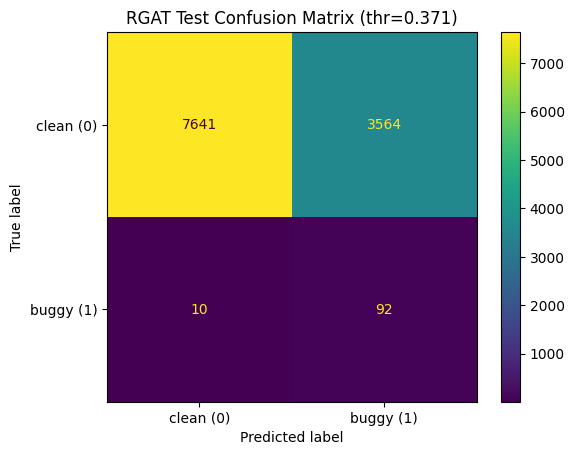

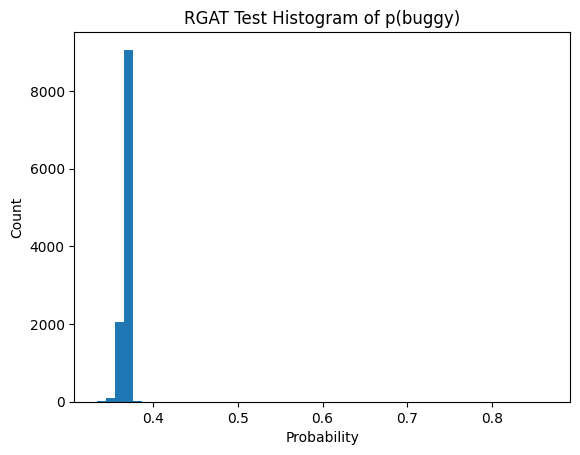

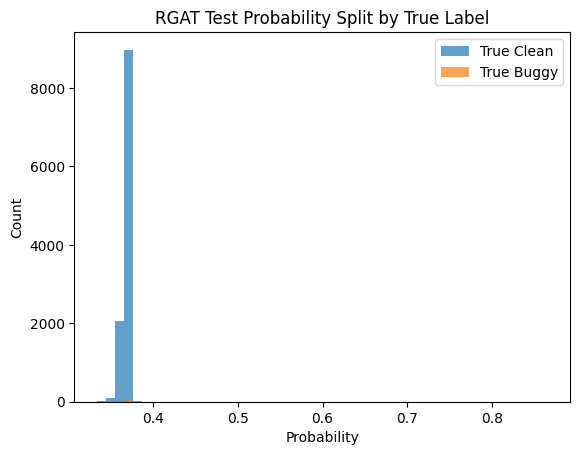

In [ ]:
y_true_test, p_buggy_test = collect_preds_graph(rgat_model, test_loader, device)

plot_confusion_and_hist(
    y_true=y_true_test,
    p_buggy=p_buggy_test,
    thr=rgat_test_metrics["best_thr"],
    title_prefix="RGAT Test"
)

<Figure size 640x480 with 0 Axes>

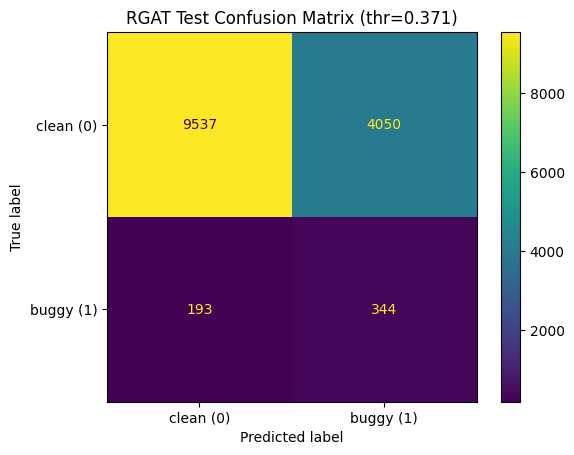

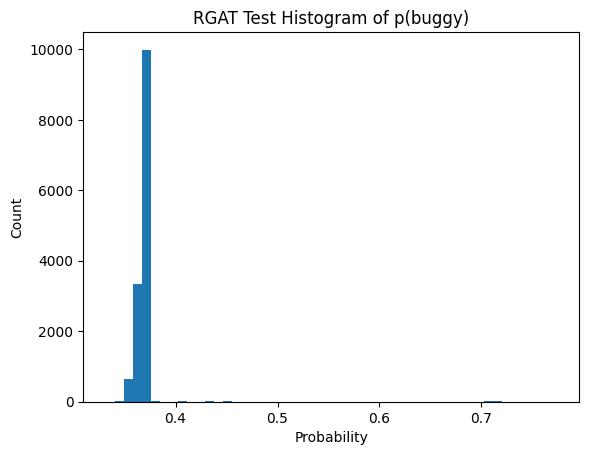

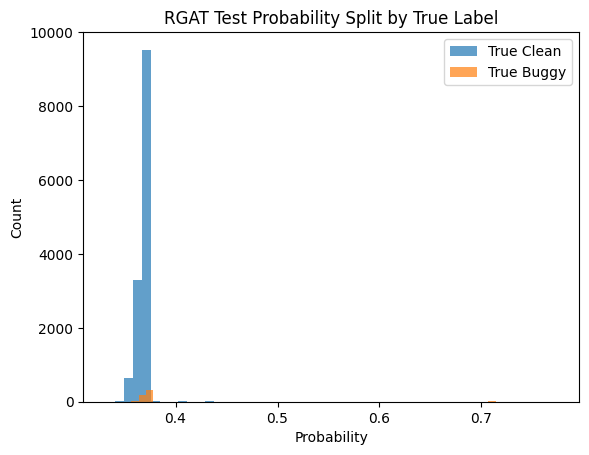

In [ ]:
y_true_val, p_buggy_val = collect_preds_graph(rgat_model, val_loader, device)

plot_confusion_and_hist(
    y_true=y_true_val,
    p_buggy=p_buggy_val,
    thr=rgat_test_metrics["best_thr"],
    title_prefix="RGAT Test"
)

<Figure size 640x480 with 0 Axes>

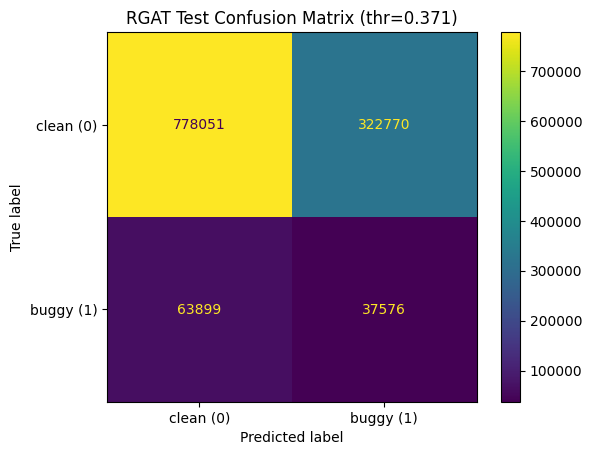

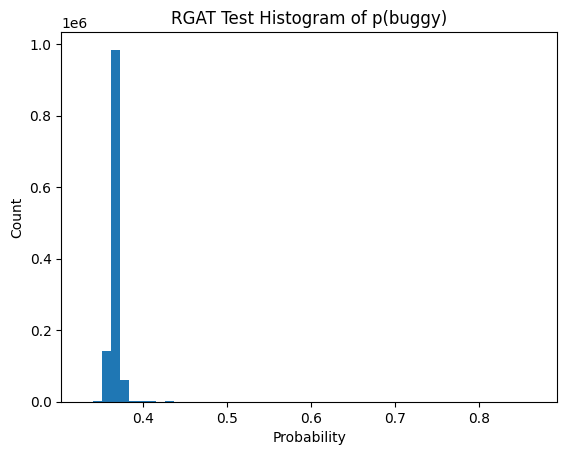

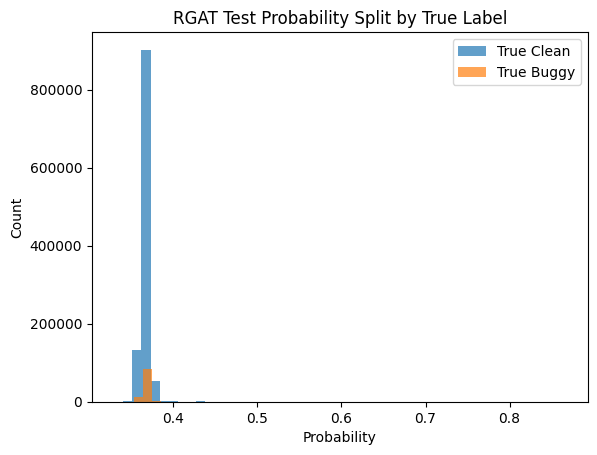

In [ ]:
y_true_train, p_buggy_train = collect_preds_graph(rgat_model, train_loader, device)

plot_confusion_and_hist(
    y_true=y_true_train,
    p_buggy=p_buggy_train,
    thr=rgat_test_metrics["best_thr"],
    title_prefix="RGAT Test"
)

In [ ]:
# =========================================================
# 10. Run Main Model: RGAT
# =========================================================
rgat_model = LineRGAT(
    in_dim=768,
    hid=128,
    num_relations=3,
    heads=4,
    dropout=0.3
)

rgat_model, rgat_test_metrics = run_experiment(
    model=rgat_model,
    model_name="RGAT",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    lr=2e-4,
    weight_decay=1e-2,
    max_epochs=10,
    patience=8,
    rank_w=0.5,
    margin=0.2,
    hard_k=50,
    save_path="best_rgat.pt"
)

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.47 GiB. GPU 0 has a total capacity of 14.56 GiB of which 1.41 GiB is free. Including non-PyTorch memory, this process has 13.15 GiB memory in use. Of the allocated memory 11.56 GiB is allocated by PyTorch, and 1.45 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
val_metrics = eval_model(rgat_model, val_loader)
best_val_mrr = val_metrics['topk']['mrr']
print(f"Best VAL MRR: {best_val_mrr:.4f}")

Best VAL MRR: 0.3710


In [ ]:
input_dim = next(iter(train_loader)).x.size(-1)
print("Detected input_dim:", input_dim)

Detected input_dim: 768


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data, Batch
from torch_geometric.nn import RGATConv, SAGEConv

In [ ]:
# =========================================================
# 11. Run Baseline Model: GraphSAGE
# =========================================================
import gc
gc.collect()
torch.cuda.empty_cache()

graphsage_model = LineGraphSAGE(
    in_dim=768,
    hid=128,
    dropout=0.3
)

graphsage_model, graphsage_test_metrics = run_experiment(
    model=graphsage_model,
    model_name="GraphSAGE",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    lr=2e-4,
    weight_decay=1e-2,
    max_epochs=10,
    patience=8,
    rank_w=1.0,
    margin=0.2,
    hard_k=50,
    save_path="best_graphsage.pt"
)

[GraphSAGE] Epoch 01 | loss=0.3797 | val PR-AUC=0.0577 | val BAcc=0.6169 | val F1=0.1183 | val P=0.0667 | val R=0.5233 | val HR@10=0.4444 | time=72.8s
  -> Saved new best model to best_graphsage.pt
[GraphSAGE] Epoch 02 | loss=0.3426 | val PR-AUC=0.0979 | val BAcc=0.6344 | val F1=0.1445 | val P=0.0855 | val R=0.4655 | val HR@10=0.6667 | time=70.2s
  -> Saved new best model to best_graphsage.pt
[GraphSAGE] Epoch 03 | loss=0.3114 | val PR-AUC=0.0901 | val BAcc=0.5986 | val F1=0.1087 | val P=0.0609 | val R=0.5047 | val HR@10=0.5556 | time=71.6s
  -> No improvement. patience 1/8
[GraphSAGE] Epoch 04 | loss=0.3022 | val PR-AUC=0.0976 | val BAcc=0.6399 | val F1=0.1309 | val P=0.0743 | val R=0.5512 | val HR@10=0.6667 | time=77.6s
  -> Saved new best model to best_graphsage.pt
[GraphSAGE] Epoch 05 | loss=0.2980 | val PR-AUC=0.0865 | val BAcc=0.6452 | val F1=0.1206 | val P=0.0664 | val R=0.6536 | val HR@10=0.5556 | time=74.0s
  -> Saved new best model to best_graphsage.pt
[GraphSAGE] Epoch 06 | 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in rgat_history]
pr_auc = [h["val_pr_auc"] for h in rgat_history]
hr10   = [h["val_hr10"] for h in rgat_history]

plt.figure(figsize=(9,5))
plt.plot(epochs, pr_auc, marker="o", label="PR-AUC")
plt.plot(epochs, hr10, marker="s", label="HR@10")

plt.title("RGAT Ranking Behaviour Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

RGAT threshold selected from VAL: 0.2453


<Figure size 640x480 with 0 Axes>

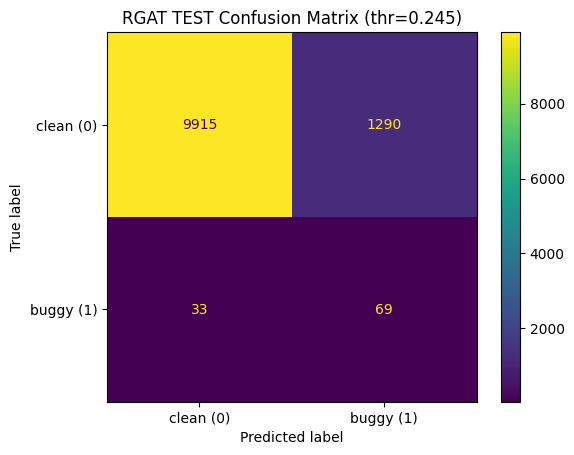

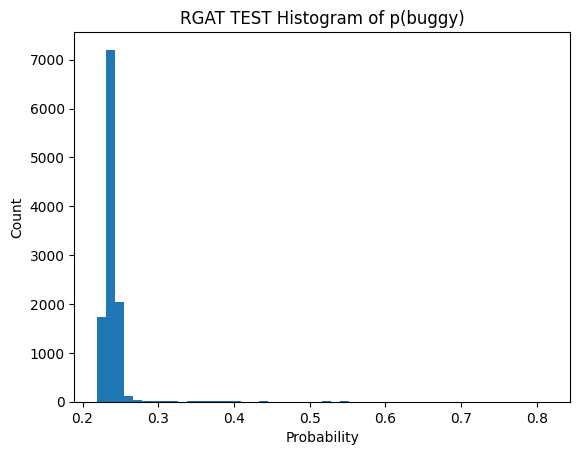

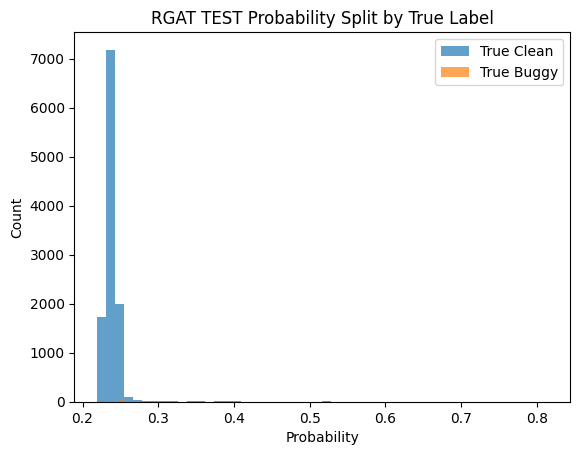

In [ ]:
# =========================================================
# 12A. RGAT Confusion Matrix and Histograms
# =========================================================
y_val_rgat, p_val_rgat = collect_preds_graph(rgat_model, val_loader, device)
thr_rgat = best_threshold_by_f1(y_val_rgat, p_val_rgat)
print("RGAT threshold selected from VAL:", round(thr_rgat, 4))

y_test_rgat, p_test_rgat = collect_preds_graph(rgat_model, test_loader, device)
plot_confusion_and_hist(
    y_test_rgat,
    p_test_rgat,
    thr=thr_rgat,
    title_prefix="RGAT TEST"
)

RGAT threshold selected from VAL for validation plots: 0.2453


<Figure size 640x480 with 0 Axes>

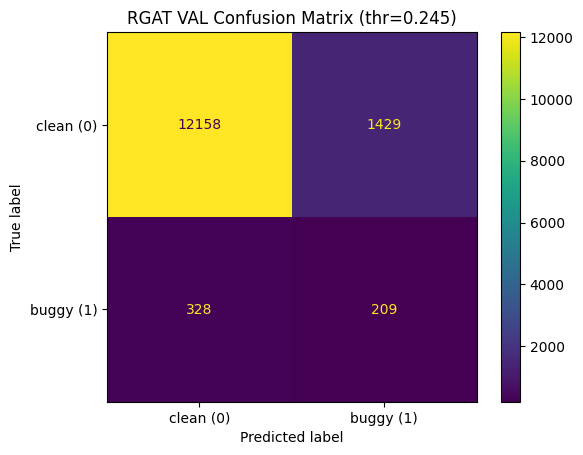

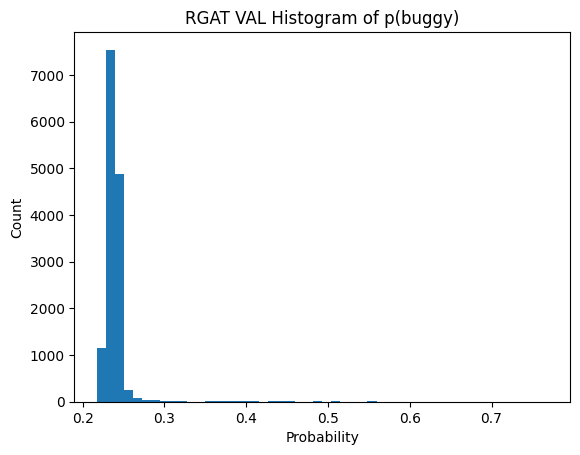

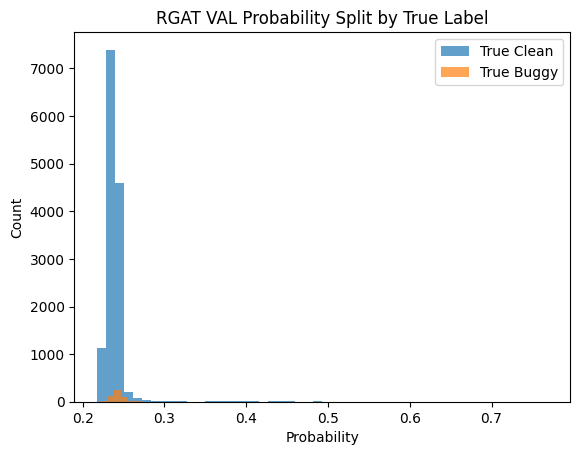

In [ ]:
y_val_rgat, p_val_rgat = collect_preds_graph(rgat_model, val_loader, device)
thr_rgat_val = best_threshold_by_f1(y_val_rgat, p_val_rgat)
print("RGAT threshold selected from VAL for validation plots:", round(thr_rgat_val, 4))

plot_confusion_and_hist(
    y_val_rgat,
    p_val_rgat,
    thr=thr_rgat_val,
    title_prefix="RGAT VAL"
)

GraphSAGE threshold selected from VAL: 0.2878


<Figure size 640x480 with 0 Axes>

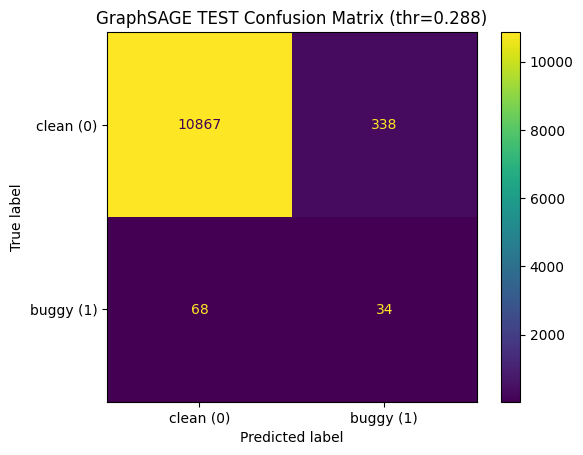

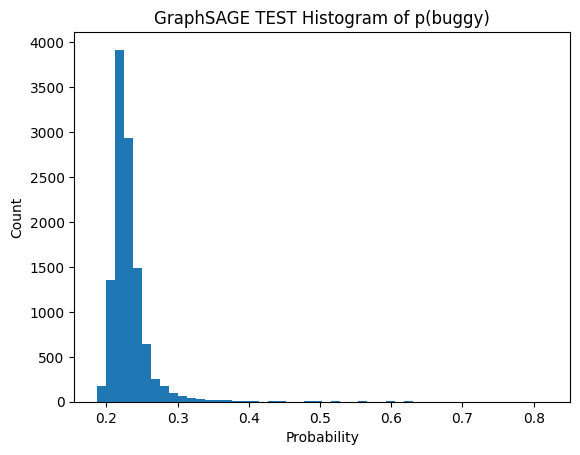

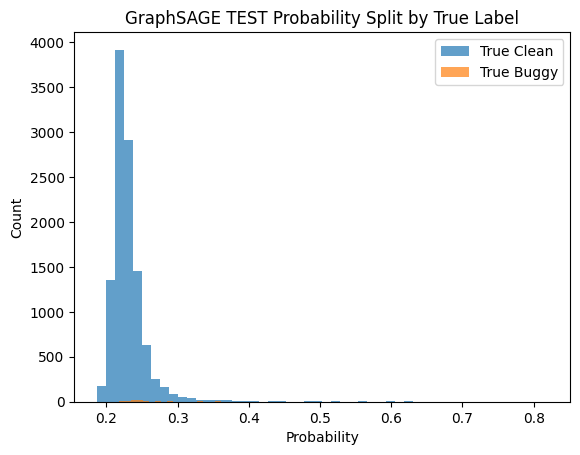

In [ ]:
# =========================================================
# 12B. GraphSAGE Confusion Matrix and Histograms
# =========================================================
y_val_sage, p_val_sage = collect_preds_graph(graphsage_model, val_loader, device)
thr_sage = best_threshold_by_f1(y_val_sage, p_val_sage)
print("GraphSAGE threshold selected from VAL:", round(thr_sage, 4))

y_test_sage, p_test_sage = collect_preds_graph(graphsage_model, test_loader, device)
plot_confusion_and_hist(
    y_test_sage,
    p_test_sage,
    thr=thr_sage,
    title_prefix="GraphSAGE TEST"
)

In [ ]:
# =========================================================
# 13. Simple Comparison Summary
# =========================================================
print("\n===== FINAL COMPARISON =====")
print("RGAT:")
print(rgat_test_metrics)

print("\nGraphSAGE:")
print(graphsage_test_metrics)


===== FINAL COMPARISON =====
RGAT:
{'PR_AUC_AP': 0.07751492295694278, 'best_thr': 0.2527729272842407, 'accuracy': 0.9639161581321305, 'precision': 0.11363636363636363, 'recall': 0.4411764705882353, 'f1': 0.18072289156626506, 'bug_rate': 0.009020960466967366, 'N': 11307, 'tn': 10854, 'fp': 351, 'fn': 57, 'tp': 45, 'topk': {'precision@1': 0.0, 'recall@1': 0.0, 'hitrate@1': 0.0, 'map@1': 0.0, 'precision@3': 0.09523809523809523, 'recall@3': 0.02460984393757503, 'hitrate@3': 0.2857142857142857, 'map@3': 0.031746031746031744, 'precision@5': 0.08571428571428573, 'recall@5': 0.04501800720288115, 'hitrate@5': 0.2857142857142857, 'map@5': 0.03333333333333333, 'precision@10': 0.11428571428571428, 'recall@10': 0.351140456182473, 'hitrate@10': 0.5714285714285714, 'map@10': 0.09173955296404276, 'precision@20': 0.0642857142857143, 'recall@20': 0.3553421368547419, 'hitrate@20': 0.5714285714285714, 'map@20': 0.09037900874635567, 'precision@50': 0.05714285714285715, 'recall@50': 0.4501800720288115, 'hi

In [ ]:
print("\n\n===== FINAL TEST RESULTS =====")

test_metrics = eval_model(rgat_model, val_loader, ks=(1,3,5,10,20,50,100))

print(f"Total lines evaluated: {test_metrics['N']}")
print(f"Bug rate: {test_metrics['bug_rate']:.4f}")

print("-" * 40)

print(f"Accuracy : {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall   : {test_metrics['recall']:.4f}")
print(f"F1 Score : {test_metrics['f1']:.4f}")

print("-" * 40)

print(f"PR-AUC   : {test_metrics['PR_AUC_AP']:.4f}")
print(f"Best threshold (F1): {test_metrics['best_thr']:.4f}")

print("-" * 40)

print("Confusion Matrix Counts:")
print(f"TN: {test_metrics['tn']}")
print(f"FP: {test_metrics['fp']}")
print(f"FN: {test_metrics['fn']}")
print(f"TP: {test_metrics['tp']}")

print("=" * 50)

print_topk(
    test_metrics["topk"],
    ks=(1,3,5,10,20,50,100),
    title="RGAT TEST TOP-K"
)

print(f"Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")



===== FINAL TEST RESULTS =====
Total lines evaluated: 14124
Bug rate: 0.0380
----------------------------------------
Accuracy : 0.8756
Precision: 0.1276
Recall   : 0.3892
F1 Score : 0.1922
----------------------------------------
PR-AUC   : 0.1030
Best threshold (F1): 0.2453
----------------------------------------
Confusion Matrix Counts:
TN: 12158
FP: 1429
FN: 328
TP: 209

===== RGAT TEST TOP-K =====
K=1 | P@1=0.2222 | R@1=0.1481 | HR@1=0.2222 | MAP@1=0.2222
K=3 | P@3=0.1481 | R@3=0.2407 | HR@3=0.3333 | MAP@3=0.2037
K=5 | P@5=0.2222 | R@5=0.3470 | HR@5=0.7778 | MAP@5=0.2748
K=10 | P@10=0.1333 | R@10=0.3484 | HR@10=0.7778 | MAP@10=0.2711
K=20 | P@20=0.0889 | R@20=0.3609 | HR@20=0.7778 | MAP@20=0.2684
K=50 | P@50=0.1067 | R@50=0.4263 | HR@50=0.8889 | MAP@50=0.2808
K=100 | P@100=0.0967 | R@100=0.5978 | HR@100=1.0000 | MAP@100=0.2976
MRR=0.3710
files_used=9


In [ ]:
print("\n\n===== FINAL TEST RESULTS =====")

test_metrics = eval_model(rgat_model, test_loader, ks=(1,3,5,10,20,50,100))

print(f"Total lines evaluated: {test_metrics['N']}")
print(f"Bug rate: {test_metrics['bug_rate']:.4f}")

print("-" * 40)

print(f"Accuracy : {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall   : {test_metrics['recall']:.4f}")
print(f"F1 Score : {test_metrics['f1']:.4f}")

print("-" * 40)

print(f"PR-AUC   : {test_metrics['PR_AUC_AP']:.4f}")
print(f"Best threshold (F1): {test_metrics['best_thr']:.4f}")

print("-" * 40)

print("Confusion Matrix Counts:")
print(f"TN: {test_metrics['tn']}")
print(f"FP: {test_metrics['fp']}")
print(f"FN: {test_metrics['fn']}")
print(f"TP: {test_metrics['tp']}")

print("=" * 50)

print_topk(
    test_metrics["topk"],
    ks=(1,3,5,10,20,50,100),
    title="RGAT TEST TOP-K"
)

print(f"Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")



===== FINAL TEST RESULTS =====
Total lines evaluated: 11307
Bug rate: 0.0090
----------------------------------------
Accuracy : 0.9639
Precision: 0.1136
Recall   : 0.4412
F1 Score : 0.1807
----------------------------------------
PR-AUC   : 0.0775
Best threshold (F1): 0.2528
----------------------------------------
Confusion Matrix Counts:
TN: 10854
FP: 351
FN: 57
TP: 45

===== RGAT TEST TOP-K =====
K=1 | P@1=0.0000 | R@1=0.0000 | HR@1=0.0000 | MAP@1=0.0000
K=3 | P@3=0.0952 | R@3=0.0246 | HR@3=0.2857 | MAP@3=0.0317
K=5 | P@5=0.0857 | R@5=0.0450 | HR@5=0.2857 | MAP@5=0.0333
K=10 | P@10=0.1143 | R@10=0.3511 | HR@10=0.5714 | MAP@10=0.0917
K=20 | P@20=0.0643 | R@20=0.3553 | HR@20=0.5714 | MAP@20=0.0904
K=50 | P@50=0.0571 | R@50=0.4502 | HR@50=0.5714 | MAP@50=0.1020
K=100 | P@100=0.0457 | R@100=0.5006 | HR@100=0.5714 | MAP@100=0.1143
MRR=0.1449
files_used=7


In [ ]:
print("\n\n===== FINAL TEST RESULTS =====")

test_metrics = eval_model(graphsage_model, test_loader, ks=(1,3,5,10,20,50,100))

print(f"Total lines evaluated: {test_metrics['N']}")
print(f"Bug rate: {test_metrics['bug_rate']:.4f}")

print("-" * 40)

print(f"Accuracy : {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall   : {test_metrics['recall']:.4f}")
print(f"F1 Score : {test_metrics['f1']:.4f}")

print("-" * 40)

print(f"PR-AUC   : {test_metrics['PR_AUC_AP']:.4f}")
print(f"Best threshold (F1): {test_metrics['best_thr']:.4f}")

print("-" * 40)

print("Confusion Matrix Counts:")
print(f"TN: {test_metrics['tn']}")
print(f"FP: {test_metrics['fp']}")
print(f"FN: {test_metrics['fn']}")
print(f"TP: {test_metrics['tp']}")

print("=" * 50)

print_topk(
    test_metrics["topk"],
    ks=(1,3,5,10,20,50,100),
    title="GraphSAGE TEST TOP-K"
)

print(f"Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")



===== FINAL TEST RESULTS =====
Total lines evaluated: 11307
Bug rate: 0.0090
----------------------------------------
Accuracy : 0.9810
Precision: 0.1258
Recall   : 0.1863
F1 Score : 0.1502
----------------------------------------
PR-AUC   : 0.0605
Best threshold (F1): 0.3235
----------------------------------------
Confusion Matrix Counts:
TN: 11073
FP: 132
FN: 83
TP: 19

===== GraphSAGE TEST TOP-K =====
K=1 | P@1=0.1429 | R@1=0.1429 | HR@1=0.1429 | MAP@1=0.1429
K=3 | P@3=0.1429 | R@3=0.1837 | HR@3=0.2857 | MAP@3=0.1984
K=5 | P@5=0.1429 | R@5=0.2517 | HR@5=0.5714 | MAP@5=0.1929
K=10 | P@10=0.1286 | R@10=0.3553 | HR@10=0.7143 | MAP@10=0.2232
K=20 | P@20=0.0786 | R@20=0.3637 | HR@20=0.7143 | MAP@20=0.2229
K=50 | P@50=0.0486 | R@50=0.4052 | HR@50=0.7143 | MAP@50=0.2270
K=100 | P@100=0.0314 | R@100=0.4424 | HR@100=0.7143 | MAP@100=0.2304
MRR=0.3001
files_used=7


In [ ]:
print("\n\n================ MODEL COMPARISON ================")
print(f"{'Model':<15} {'PR-AUC':<10} {'F1':<10} {'Precision':<10} {'Recall':<10} {'HR@10':<10} {'MRR':<10}")
print("-" * 75)

rgat_hr10 = rgat_test_metrics["topk"].get("hitrate@10", 0.0)
rgat_mrr = rgat_test_metrics["topk"].get("mrr", 0.0)

sage_hr10 = graphsage_test_metrics["topk"].get("hitrate@10", 0.0)
sage_mrr = graphsage_test_metrics["topk"].get("mrr", 0.0)

print(f"{'RGAT (Proposed)':<15} "
      f"{rgat_test_metrics['PR_AUC_AP']:<10.4f} "
      f"{rgat_test_metrics['f1']:<10.4f} "
      f"{rgat_test_metrics['precision']:<10.4f} "
      f"{rgat_test_metrics['recall']:<10.4f} "
      f"{rgat_hr10:<10.4f} "
      f"{rgat_mrr:<10.4f}")

print(f"{'GraphSAGE':<15} "
      f"{graphsage_test_metrics['PR_AUC_AP']:<10.4f} "
      f"{graphsage_test_metrics['f1']:<10.4f} "
      f"{graphsage_test_metrics['precision']:<10.4f} "
      f"{graphsage_test_metrics['recall']:<10.4f} "
      f"{sage_hr10:<10.4f} "
      f"{sage_mrr:<10.4f}")

print("=" * 75)



================ MODEL COMPARISON ================
Model           PR-AUC     F1         Precision  Recall     HR@10      MRR       
---------------------------------------------------------------------------
RGAT (Proposed) 0.0775     0.1807     0.1136     0.4412     0.5714     0.1449    
GraphSAGE       0.0631     0.1630     0.1310     0.2157     0.5714     0.2733    


In [ ]:
import pandas as pd
import torch
from collections import defaultdict

@torch.no_grad()
def compare_predicted_vs_true_buggy_lines(model, loader, device, threshold=0.3, top_n_files=None):
    """
    Compare true buggy lines vs predicted buggy lines at file level.

    Returns a dataframe with one row per file:
      filepath, commit, true_buggy_lines, predicted_buggy_lines, matched_lines
    """
    model.eval()
    merged = {}

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)
        p_bug = torch.softmax(logits, dim=-1)[:, 1]
        y = batch.y
        g_local = batch.batch

        data_list = batch.to_data_list()

        for g in range(batch.num_graphs):
            idx = (g_local == g).nonzero(as_tuple=True)[0]
            if idx.numel() == 0:
                continue

            meta = data_list[g].meta
            commit = str(meta["commit"])
            filepath = str(meta["filepath"])
            line_start = int(meta["line_no_start"])

            probs = p_bug[idx].detach().cpu().tolist()
            labels = y[idx].detach().cpu().tolist()

            for i, (prob, label) in enumerate(zip(probs, labels)):
                line_no = line_start + i
                key = (commit, filepath, line_no)

                if key not in merged:
                    merged[key] = {
                        "p_bug": float(prob),
                        "y_true": int(label)
                    }
                else:
                    merged[key]["p_bug"] = max(merged[key]["p_bug"], float(prob))
                    merged[key]["y_true"] = max(merged[key]["y_true"], int(label))

    by_file = defaultdict(lambda: {"true": [], "pred": [], "match": []})

    for (commit, filepath, line_no), vals in merged.items():
        file_key = (commit, filepath)

        if vals["y_true"] == 1:
            by_file[file_key]["true"].append(line_no)

        if vals["p_bug"] >= threshold:
            by_file[file_key]["pred"].append(line_no)

    rows = []
    for (commit, filepath), vals in by_file.items():
        true_lines = sorted(set(vals["true"]))
        pred_lines = sorted(set(vals["pred"]))
        matched = sorted(set(true_lines).intersection(pred_lines))

        rows.append({
            "commit": commit,
            "filepath": filepath,
            "true_buggy_lines": true_lines,
            "predicted_buggy_lines": pred_lines,
            "matched_lines": matched,
            "n_true": len(true_lines),
            "n_pred": len(pred_lines),
            "n_matched": len(matched)
        })

    df = pd.DataFrame(rows).sort_values(["n_true", "n_matched"], ascending=[False, False]).reset_index(drop=True)

    if top_n_files is not None:
        df = df.head(top_n_files)

    for _, row in df.iterrows():
        print(f"\nFile: {row['filepath']}")
        print(f"Commit: {row['commit']}")
        print(f"True buggy lines      : {row['true_buggy_lines']}")
        print(f"Predicted buggy lines : {row['predicted_buggy_lines']}")
        print(f"Matched lines         : {row['matched_lines']}")
        print("-" * 80)

    return df

In [ ]:
comparison_df = compare_predicted_vs_true_buggy_lines(
    rgat_model,
    test_loader,
    device,
    threshold=0.3
)


File: src/transformers/models/m2m_100/modeling_m2m_100.py
Commit: 8ac9b827245bd3a97b447be9dc8d9e83cd9951a9
True buggy lines      : [20, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1258, 1259, 1260, 1261, 1262, 1263, 1264, 1265, 1266, 1267, 1268, 1269, 1270, 1271, 1272, 1273, 1274]
Predicted buggy lines : [20, 42, 76, 99, 106, 192, 246, 652, 684, 745, 852, 976, 986, 992, 1016, 1027, 1088, 1150, 1173, 1217]
Matched lines         : [20, 1150]
--------------------------------------------------------------------------------

File: examples/pytorch/multiple-choice/run_swag_no_trainer.py
Commit: be752d12f8ed10b90b240c24bd8faa11031ec912
True buggy lines      : [195, 268, 488, 489, 490, 491, 576]
Predicted buggy lines : [30, 34, 54, 157, 236, 268, 489, 494, 576, 603]
Matched lines         : [268, 489, 576]
--------------------------------------------------------------------------------

File: src/transformers/modeling_flax_utils.py
Commit: 76

In [ ]:
#Prepare data for vizualization

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

@torch.no_grad()
def collect_line_predictions_with_code(model, loader, device):
    """
    Merge overlapping windows into original files using max bug probability per line.
    Returns a dataframe with:
      file_id, filepath, commit, line_no, p_bug, y_true
    """
    model.eval()
    best = {}

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)
        p_bug = torch.softmax(logits, dim=-1)[:, 1]
        y = batch.y
        g_local = batch.batch

        data_list = batch.to_data_list()

        for g in range(batch.num_graphs):
            idx = (g_local == g).nonzero(as_tuple=True)[0]
            if idx.numel() == 0:
                continue

            meta = data_list[g].meta
            commit = str(meta["commit"])
            filepath = str(meta["filepath"])
            line0 = int(meta["line_no_start"])
            file_id = f"{commit}:{filepath}"

            pb = p_bug[idx].detach().cpu().tolist()
            yy = y[idx].detach().cpu().tolist()

            for i, (prob, label) in enumerate(zip(pb, yy)):
                line_no = line0 + i
                key = (file_id, filepath, commit, line_no)

                if key not in best:
                    best[key] = [float(prob), int(label)]
                else:
                    best[key][0] = max(best[key][0], float(prob))
                    best[key][1] = max(best[key][1], int(label))

    rows = []
    for (file_id, filepath, commit, line_no), (p_bug, y_true) in best.items():
        rows.append({
            "file_id": file_id,
            "filepath": filepath,
            "commit": commit,
            "line_no": line_no,
            "p_bug": p_bug,
            "y_true": y_true
        })

    df = pd.DataFrame(rows).sort_values(["filepath", "line_no"]).reset_index(drop=True)
    return df

In [ ]:
def plot_bug_probability_heatmap(df, filepath, save_path=None, max_lines=None):
    """
    Heatmap of predicted bug probability over source code lines for a single file.
    True buggy lines are marked with red dots.
    """
    sub = df[df["filepath"] == filepath].copy().sort_values("line_no")
    if len(sub) == 0:
        print(f"No predictions found for file: {filepath}")
        return

    if max_lines is not None:
        sub = sub.head(max_lines)

    line_numbers = sub["line_no"].tolist()
    probs = sub["p_bug"].values.reshape(1, -1)
    true_buggy = sub["y_true"].values

    plt.figure(figsize=(max(10, len(line_numbers) * 0.15), 2.8))
    plt.imshow(probs, aspect="auto")
    plt.colorbar(label="Predicted bug probability")
    plt.yticks([0], ["Bug\nProbability"])

    tick_idx = np.linspace(0, len(line_numbers) - 1, min(15, len(line_numbers))).astype(int)
    plt.xticks(tick_idx, [line_numbers[i] for i in tick_idx], rotation=45)
    plt.xlabel("Line number")
    plt.title(f"Bug Probability Heatmap\n{os.path.basename(filepath)}")

    for i, is_buggy in enumerate(true_buggy):
        if is_buggy == 1:
            plt.scatter(i, 0, marker="o", s=20)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

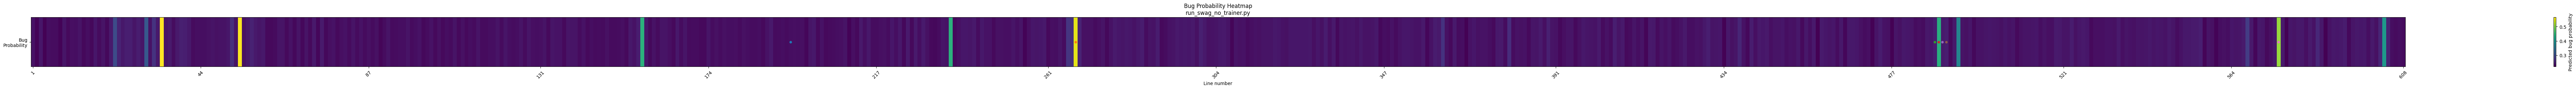

In [ ]:
line_df = collect_line_predictions_with_code(rgat_model, test_loader, device)

example_file = line_df["filepath"].iloc[0]
plot_bug_probability_heatmap(
    line_df,
    filepath=example_file,
    save_path="bug_probability_heatmap.png"
)

This prints the code with markers:

>>> PRED for predicted buggy lines

>>> TRUE for actual buggy lines

>>> BOTH if both predicted and truE

In [ ]:
import requests
import torch
import pandas as pd

SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "line-level-bug-dataset/1.0"})


def norm_path(filepath):
    return str(filepath).replace("\\", "/").lstrip("/")


def github_raw_url(owner, repo, ref, filepath):
    path = norm_path(filepath)
    return f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}"


def fetch_github_text(owner, repo, commit, filepath):
    url = github_raw_url(owner, repo, commit, filepath)
    r = SESSION.get(url, timeout=30)

    if r.status_code == 200:
        return r.text.replace("\r\n", "\n").replace("\r", "\n")

    for ref in ("main", "master"):
        url2 = github_raw_url(owner, repo, ref, filepath)
        r2 = SESSION.get(url2, timeout=30)
        if r2.status_code == 200:
            return r2.text.replace("\r\n", "\n").replace("\r", "\n")

    raise RuntimeError(f"Fetch failed {r.status_code}: {url}")


@torch.no_grad()
def collect_line_predictions_with_code(model, loader, device, default_owner="huggingface", default_repo="transformers"):
    """
    Returns dataframe with:
      owner, repo, commit, filepath, line_no, p_bug, y_true
    """
    model.eval()
    best = {}

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)
        p_bug = torch.softmax(logits, dim=-1)[:, 1]
        y = batch.y
        g_local = batch.batch
        data_list = batch.to_data_list()

        for g in range(batch.num_graphs):
            idx = (g_local == g).nonzero(as_tuple=True)[0]
            if idx.numel() == 0:
                continue

            meta = data_list[g].meta

            owner = str(meta.get("owner", "")).strip() or default_owner
            repo = str(meta.get("repo", "")).strip() or default_repo
            commit = str(meta["commit"])
            filepath = str(meta["filepath"])
            line0 = int(meta["line_no_start"])

            pb = p_bug[idx].detach().cpu().tolist()
            yy = y[idx].detach().cpu().tolist()

            for i, (prob, label) in enumerate(zip(pb, yy)):
                line_no = line0 + i
                key = (owner, repo, commit, filepath, line_no)

                if key not in best:
                    best[key] = [float(prob), int(label)]
                else:
                    best[key][0] = max(best[key][0], float(prob))
                    best[key][1] = max(best[key][1], int(label))

    rows = []
    for (owner, repo, commit, filepath, line_no), (p_bug, y_true) in best.items():
        rows.append({
            "owner": owner,
            "repo": repo,
            "commit": commit,
            "filepath": filepath,
            "line_no": line_no,
            "p_bug": p_bug,
            "y_true": y_true
        })

    return pd.DataFrame(rows).sort_values(["filepath", "line_no"]).reset_index(drop=True)


def show_code_with_highlighted_buggy_lines(
    df,
    filepath,
    threshold=0.3,
    context_radius=None,
    max_lines=None
):
    sub = df[df["filepath"] == filepath].copy().sort_values("line_no")
    if len(sub) == 0:
        print(f"No predictions found for file: {filepath}")
        return

    owner = str(sub["owner"].iloc[0]).strip()
    repo = str(sub["repo"].iloc[0]).strip()
    commit = str(sub["commit"].iloc[0]).strip()

    try:
        text = fetch_github_text(owner, repo, commit, filepath)
        source_lines = text.splitlines()
    except Exception as e:
        print(f"Could not fetch file: {filepath}")
        print("Reason:", e)
        return

    pred_lines = set(sub.loc[sub["p_bug"] >= threshold, "line_no"].tolist())
    true_lines = set(sub.loc[sub["y_true"] == 1, "line_no"].tolist())

    if context_radius is not None:
        keep = set()
        for ln in sorted(pred_lines | true_lines):
            for x in range(max(1, ln - context_radius), min(len(source_lines), ln + context_radius) + 1):
                keep.add(x)
        selected_lines = sorted(keep)
    else:
        selected_lines = list(range(1, len(source_lines) + 1))

    if max_lines is not None:
        selected_lines = selected_lines[:max_lines]

    print(f"\n===== CODE VIEW =====")
    print(f"Owner : {owner}")
    print(f"Repo  : {repo}")
    print(f"Commit: {commit}")
    print(f"File  : {filepath}\n")

    for ln in selected_lines:
        code = source_lines[ln - 1] if 1 <= ln <= len(source_lines) else "[Line not found]"

        is_pred = ln in pred_lines
        is_true = ln in true_lines

        if is_pred and is_true:
            tag = ">>> BOTH"
        elif is_pred:
            tag = ">>> PRED"
        elif is_true:
            tag = ">>> TRUE"
        else:
            tag = "         "

        prob_row = sub[sub["line_no"] == ln]
        prob = float(prob_row["p_bug"].iloc[0]) if len(prob_row) else 0.0

        print(f"{tag}  Line {ln:4d} | p={prob:.4f} | {code}")

In [ ]:
line_df = collect_line_predictions_with_code(
    rgat_model,
    test_loader,
    device,
    default_owner="huggingface",
    default_repo="transformers"
)

example_file = "examples/pytorch/multiple-choice/run_swag_no_trainer.py"

show_code_with_highlighted_buggy_lines(
    line_df,
    filepath=example_file,
    threshold=0.3,
    context_radius=3
)


===== CODE VIEW =====
Owner : huggingface
Repo  : transformers
Commit: be752d12f8ed10b90b240c24bd8faa11031ec912
File  : examples/pytorch/multiple-choice/run_swag_no_trainer.py

           Line   27 | p=0.2405 | from dataclasses import dataclass
           Line   28 | p=0.2487 | from itertools import chain
           Line   29 | p=0.2408 | from pathlib import Path
>>> PRED  Line   30 | p=0.3162 | from typing import Optional, Union
           Line   31 | p=0.2378 | 
           Line   32 | p=0.2717 | import datasets
           Line   33 | p=0.2439 | import torch
>>> PRED  Line   34 | p=0.5651 | from datasets import load_dataset, load_metric
           Line   35 | p=0.2406 | from torch.utils.data import DataLoader
           Line   36 | p=0.2454 | from tqdm.auto import tqdm
           Line   37 | p=0.2327 | 
           Line   51 | p=0.2415 |     default_data_collator,
           Line   52 | p=0.2665 |     get_scheduler,
           Line   53 | p=0.2395 | )
>>> PRED  Line   54 | p=0.5623 | 

# Top-10 suspicious files visualization

This ranks files by suspiciousness using:

max line probability

mean top-k probability

number of predicted suspicious lines

In [ ]:
def plot_top_suspicious_files(df, top_n=10, suspicious_threshold=0.3, save_path=None):
    """
    Visualize top suspicious files based on line-level probabilities.
    """
    rows = []

    for filepath, sub in df.groupby("filepath"):
        probs = sub["p_bug"].values
        probs_sorted = np.sort(probs)[::-1]

        top5_mean = probs_sorted[:min(5, len(probs_sorted))].mean()
        max_prob = probs_sorted[0]
        suspicious_count = int((sub["p_bug"] >= suspicious_threshold).sum())
        true_buggy_count = int(sub["y_true"].sum())

        score = 0.6 * max_prob + 0.4 * top5_mean

        rows.append({
            "filepath": filepath,
            "score": score,
            "max_prob": max_prob,
            "top5_mean": top5_mean,
            "suspicious_count": suspicious_count,
            "true_buggy_count": true_buggy_count
        })

    rank_df = pd.DataFrame(rows).sort_values("score", ascending=False).head(top_n)

    plt.figure(figsize=(10, max(5, top_n * 0.5)))
    y_labels = [os.path.basename(x) for x in rank_df["filepath"]]
    scores = rank_df["score"].values

    plt.barh(y_labels[::-1], scores[::-1])
    plt.xlabel("Suspicion score")
    plt.title(f"Top-{top_n} Suspicious Files")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    return rank_df

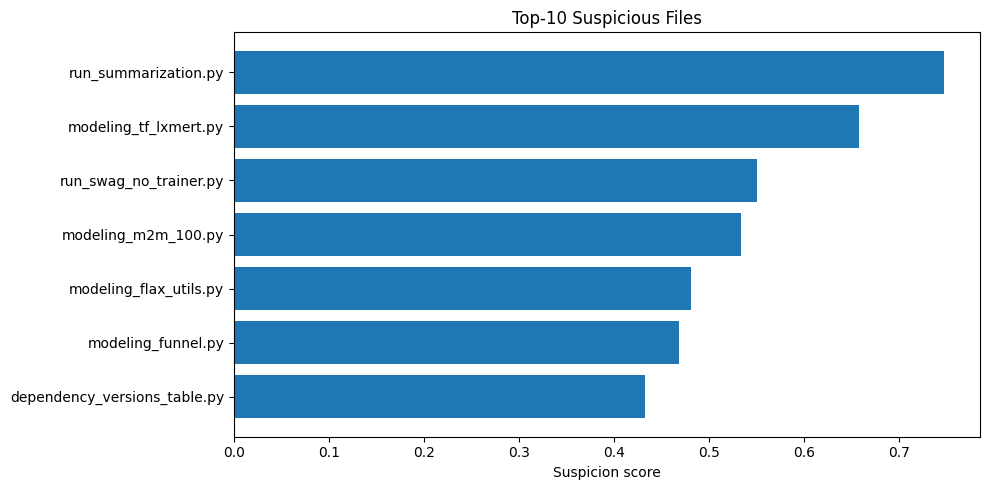

,filepath,score,max_prob,top5_mean,suspicious_count,true_buggy_count
1,examples/pytorch/summarization/run_summarizati...,0.747307,0.814573,0.646407,11,3
5,src/transformers/models/lxmert/modeling_tf_lxm...,0.657280,0.712631,0.574253,26,2
0,examples/pytorch/multiple-choice/run_swag_no_t...,0.549738,0.565120,0.526665,10,7
6,src/transformers/models/m2m_100/modeling_m2m_1...,0.533651,0.556508,0.499367,20,34
3,src/transformers/modeling_flax_utils.py,0.480683,0.500732,0.450610,9,7
4,src/transformers/modeling_funnel.py,0.468494,0.499614,0.421814,10,3
2,src/transformers/dependency_versions_table.py,0.432217,0.463816,0.384817,6,1


In [ ]:
top_files_df = plot_top_suspicious_files(
    line_df,
    top_n=10,
    suspicious_threshold=0.3,
    save_path="top10_suspicious_files.png"
)

top_files_df

In [ ]:
def generate_case_study_visuals(
    model,
    loader,
    device,
    threshold=0.3,
    default_owner="huggingface",
    default_repo="transformers"
):
    df = collect_line_predictions_with_code(
        model,
        loader,
        device,
        default_owner=default_owner,
        default_repo=default_repo
    )

    top_files = plot_top_suspicious_files(
        df,
        top_n=10,
        suspicious_threshold=threshold,
        save_path="top10_suspicious_files.png"
    )

    if len(top_files) == 0:
        print("No files available.")
        return df, top_files

    best_file = top_files.iloc[0]["filepath"]
    print("\nMost suspicious file:", best_file)

    plot_bug_probability_heatmap(
        df,
        filepath=best_file,
        save_path="most_suspicious_file_heatmap.png"
    )

    show_code_with_highlighted_buggy_lines(
        df,
        filepath=best_file,
        threshold=threshold,
        context_radius=3
    )

    return df, top_files

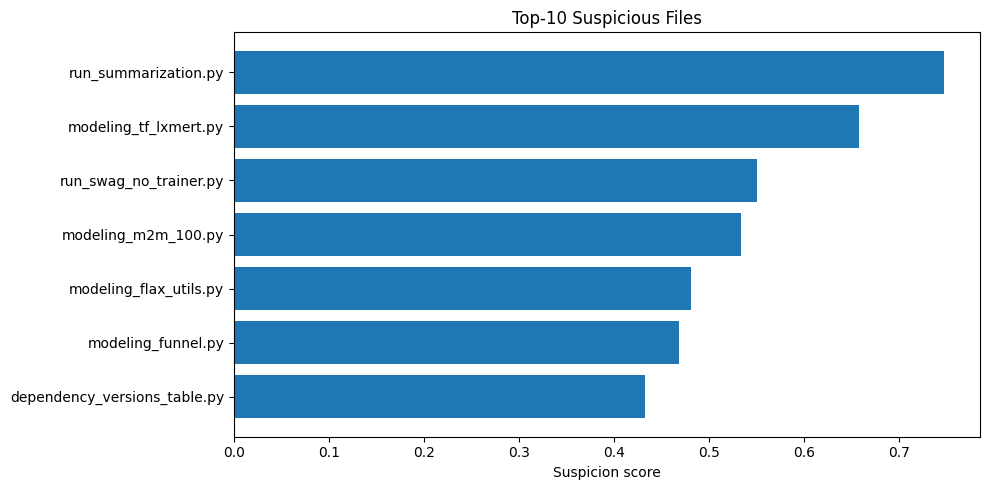


Most suspicious file: examples/pytorch/summarization/run_summarization.py


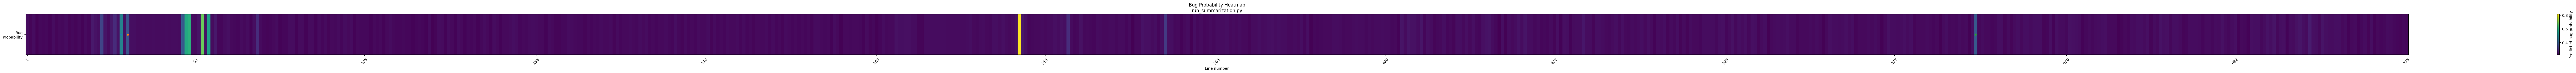


===== CODE VIEW =====
Owner : huggingface
Repo  : transformers
Commit: 1f843991716bba3b73071f1a2d819b0aebc05375
File  : examples/pytorch/summarization/run_summarization.py

           Line   21 | p=0.2620 | import logging
           Line   22 | p=0.2508 | import os
           Line   23 | p=0.2419 | import sys
>>> PRED  Line   24 | p=0.3427 | from dataclasses import dataclass, field
           Line   25 | p=0.2516 | from typing import Optional
           Line   26 | p=0.2377 | 
           Line   27 | p=0.2595 | import datasets
           Line   28 | p=0.2942 | import nltk  # Here to have a nice missing dependency error message early on
           Line   29 | p=0.2493 | import numpy as np
>>> BOTH  Line   30 | p=0.4851 | from datasets import load_dataset
           Line   31 | p=0.2457 | 
>>> BOTH  Line   32 | p=0.3721 | import evaluate
           Line   33 | p=0.2418 | import transformers
           Line   34 | p=0.2424 | from filelock import FileLock
           Line   35 | p=0.2376 | 

In [ ]:
line_df, top_files_df = generate_case_study_visuals(
    rgat_model,
    test_loader,
    device,
    threshold=0.3,
    default_owner="huggingface",
    default_repo="transformers"
)

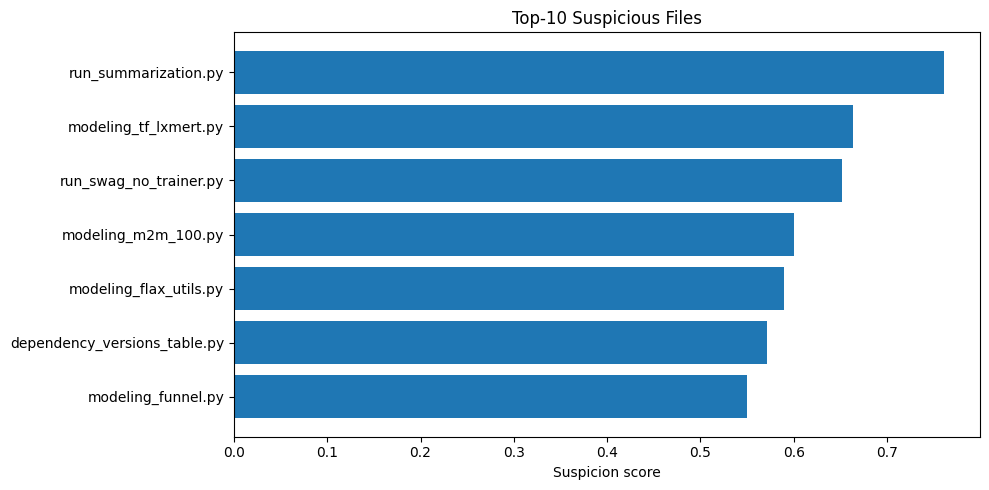


Most suspicious file: examples/pytorch/summarization/run_summarization.py


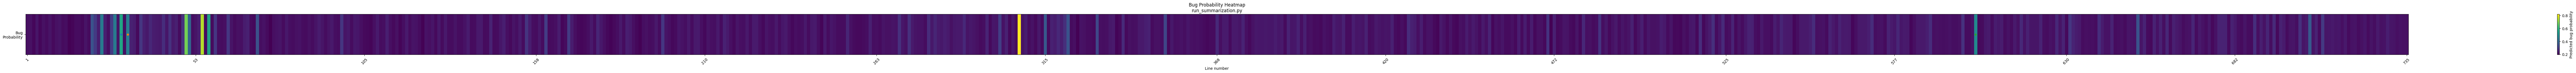


===== CODE VIEW =====
Owner : huggingface
Repo  : transformers
Commit: 1f843991716bba3b73071f1a2d819b0aebc05375
File  : examples/pytorch/summarization/run_summarization.py

           Line   18 | p=0.2082 | """
           Line   19 | p=0.2262 | # You can also adapt this script on your own sequence to sequence task. Pointers for this are left as comments.
           Line   20 | p=0.2119 | 
>>> PRED  Line   21 | p=0.3510 | import logging
           Line   22 | p=0.2998 | import os
           Line   23 | p=0.2448 | import sys
>>> PRED  Line   24 | p=0.4486 | from dataclasses import dataclass, field
           Line   25 | p=0.2473 | from typing import Optional
           Line   26 | p=0.2166 | 
>>> PRED  Line   27 | p=0.3050 | import datasets
>>> PRED  Line   28 | p=0.4504 | import nltk  # Here to have a nice missing dependency error message early on
           Line   29 | p=0.2265 | import numpy as np
>>> BOTH  Line   30 | p=0.5620 | from datasets import load_dataset
           Line   31

In [ ]:
line_df_sage, top_files_df_sage = generate_case_study_visuals(
    graphsage_model,
    test_loader,
    device,
    threshold=0.3,
    default_owner="huggingface",
    default_repo="transformers"
)

Important note

GraphSAGE does not use edge_type, so you do not need to change your dataset or collate code.
It will simply ignore data.edge_type.

Normal Codes

# GAT fusion and dual-head model

Edge-type embeddings: Inject coarse edge-type info into GAT via an augmentation trick.

Residuals and normalization: Keep features stable and avoid over-smoothing.

Heads:

Line-level sigmoid for per-line probabilities
File-level attention pooling + MLP for buggy vs clean

## Generate Qualitative Defect Localization Visuals

### Subtask:
Execute the `generate_case_study_visuals` function to produce and display visualizations for line-level defect localization using the RGAT model on the test dataset. This includes plotting a heatmap of bug probabilities for the most suspicious file and showing the source code with predicted and true buggy lines highlighted.


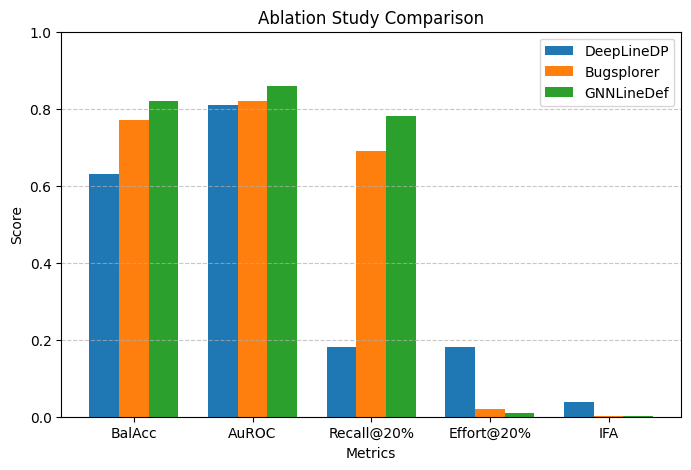

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your table
metrics = ['BalAcc', 'AuROC', 'Recall@20%', 'Effort@20%', 'IFA']

deeplineDP = [0.63, 0.81, 0.18, 0.18, 0.038]
bugsplorer = [0.77, 0.82, 0.69, 0.02, 0.001]
gnnlinedef = [0.82, 0.86, 0.78, 0.01, 0.001]

# X-axis positions
x = np.arange(len(metrics))
width = 0.25  # bar width

# Create figure
plt.figure(figsize=(8,5))

# Plot bars
plt.bar(x - width, deeplineDP, width, label='DeepLineDP')
plt.bar(x, bugsplorer, width, label='Bugsplorer')
plt.bar(x + width, gnnlinedef, width, label='GNNLineDef')

# Labels and formatting
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Ablation Study Comparison')
plt.xticks(x, metrics)
plt.ylim(0, 1)

# Show legend
plt.legend()

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()